# Prevendo o Índice de Mortalidade na UTI por Sepse

Neste projeto desenvolvido no Laboratório de Bioengenharia do ITA, construirei um modelo de machine learning para prever a probabilidade de mortalidade de pacientes com sepse internados na UTI. Trata-se de um problema de aprendizado supervisionado (com um conjunto de dados rotulado) para classificação, onde a variável-alvo será 1 se o paciente veio a óbito e 0 caso contrário.

Seguirei um pipeline estruturado para o desenvolvimento do modelo:

1. **Introdução ao problema** – Compreender os impactos da sepse e a necessidade de um modelo preditivo eficiente.  
2. **Coletar e organizar os dados** – Utilizar a base MIMIC-IV e obter uma visão geral das variáveis disponíveis.   
3. **Pré-processamento** – Limpar os dados, lidar com valores ausentes e selecionar variáveis relevantes.
4. **Análise exploratória dos dados (EDA)** – Identificar padrões, visualizar distribuições e verificar correlações.  
5. **Treinamento e comparação de modelos** – Testar diferentes algoritmos de machine learning, ajustar hiperparâmetros e selecionar o melhor modelo.  
6. **Avaliação do modelo final** – Validar o desempenho no conjunto de teste e interpretar os resultados.  
7. **Conclusões e recomendações** – Identificar insights para auxiliar no manejo clínico da sepse.   

Neste notebook, realizarei a **análise exploratória dos dados (EDA)**, cobrindo as etapas **1 a 4** do pipeline acima. O objetivo principal é extrair insights que possam revelar padrões relevantes sobre os pacientes com maior risco de mortalidade. Mesmo antes de construir o modelo, essa análise pode ajudar profissionais de saúde a identificar fatores críticos associados à sepse. Além disso, cada etapa será detalhada para justificar as decisões tomadas ao longo do processo.

## 1. Introdução ao problema

No Brasil, a sepse representa um desafio significativo de saúde pública. Anualmente, são registrados cerca de 400 mil casos de sepse em adultos, dos quais aproximadamente 240 mil resultam em óbito, indicando uma taxa de mortalidade de 60%. Entre as crianças, são 42 mil casos anuais, com 8 mil mortes, correspondendo a 19% de mortalidade. [Mortalidade da Sepsis no Brasil](https://www.gov.br/ebserh/pt-br/hospitais-universitarios/regiao-sudeste/hu-ufjf/comunicacao/noticias/2023/dia-mundial-da-sepse-brasil-tem-alta-taxa-de-mortalidade-por-sepse-dentre-os-paises-em-desenvolvimento?utm_source=chatgpt.com)

Modelos de machine learning têm se mostrado promissores na identificação precoce de pacientes com maior risco de óbito, analisando variáveis como dados demográficos, sinais vitais e históricos médicos. Estudos já demonstraram que esses algoritmos podem superar métodos convencionais na previsão de mortalidade por sepse, melhorando a precisão das decisões clínicas e possibilitando intervenções mais eficazes. [Machine-learning models for prediction of sepsis patients mortality](https://www.medintensiva.org/en-machine-learning-models-for-prediction-sepsis-articulo-S2173572722003101)

A aplicação dessas abordagens na prática hospitalar pode otimizar o tratamento e reduzir significativamente a mortalidade, alinhando-se às tendências de inovação em cuidados intensivos.



## 2. Coletar e explorar os dados

A **MIMIC-IV (Medical Information Mart for Intensive Care)** é um banco de dados hospitalar desenvolvido pelo **MIT** em parceria com o **Beth Israel Deaconess Medical Center**, contendo informações anonimizadas de pacientes internados em UTIs. Ele inclui dados clínicos, laboratoriais e administrativos, sendo amplamente utilizado para pesquisas em saúde e machine learning.

<span style="color: red;">**Aviso:** </span>Em **2** não vamos fazer nada de EDA, os únicos gráficos que foram feitos foi para preparar e limpar os dados para a EDA, e
nela sim temos visualizações de categorias, distribuições, etc.

### Carregando database

Utilizaremos as databases do MIMIC-IV:

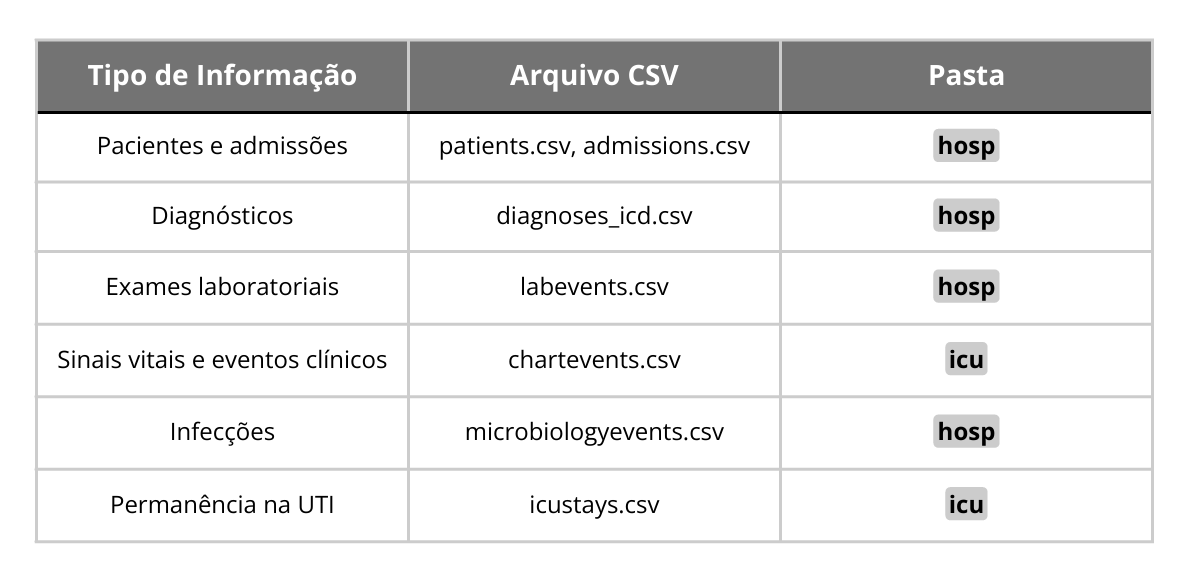

### Verificando as admissões

In [2]:
import pandas as pd
admissions = pd.read_csv("C:\\Users\\Felipe 1\\Downloads\\mimic-iv-3.0\\mimic-iv-3.0\\hosp\\admissions.csv\\admissions.csv")
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [3]:
diagnoses_icd = pd.read_csv("C:\\Users\\Felipe 1\\Downloads\\mimic-iv-3.0\\mimic-iv-3.0\\hosp\\diagnoses_icd.csv\\diagnoses_icd.csv")
# esse dataframe tem o nome da doença se quiser verificar
d_icd_diagnoses = pd.read_csv("C:\\Users\\Felipe 1\\Downloads\\mimic-iv-3.0\\mimic-iv-3.0\\hosp\\d_icd_diagnoses.csv\\d_icd_diagnoses.csv")
diagnoses_icd = diagnoses_icd.merge(d_icd_diagnoses)
diagnoses_icd.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10000032,22595853,1,5723,9,Portal hypertension
1,10000032,22595853,2,78959,9,Other ascites
2,10000032,22595853,3,5715,9,Cirrhosis of liver without mention of alcohol
3,10000032,22595853,4,07070,9,Unspecified viral hepatitis C without hepatic ...
4,10000032,22595853,5,496,9,"Chronic airway obstruction, not elsewhere clas..."


Agora vamos filtrar somente admissões diagnosticadas como Sepsis;
Primeiramente, vamos verificar quais os casos mais comuns de Sepsis no banco de dados

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\1714548709.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=qtde_sepsis.nlargest(15, 'num_diagnosticos'), x='num_diagnosticos', y='long_title', palette="viridis")


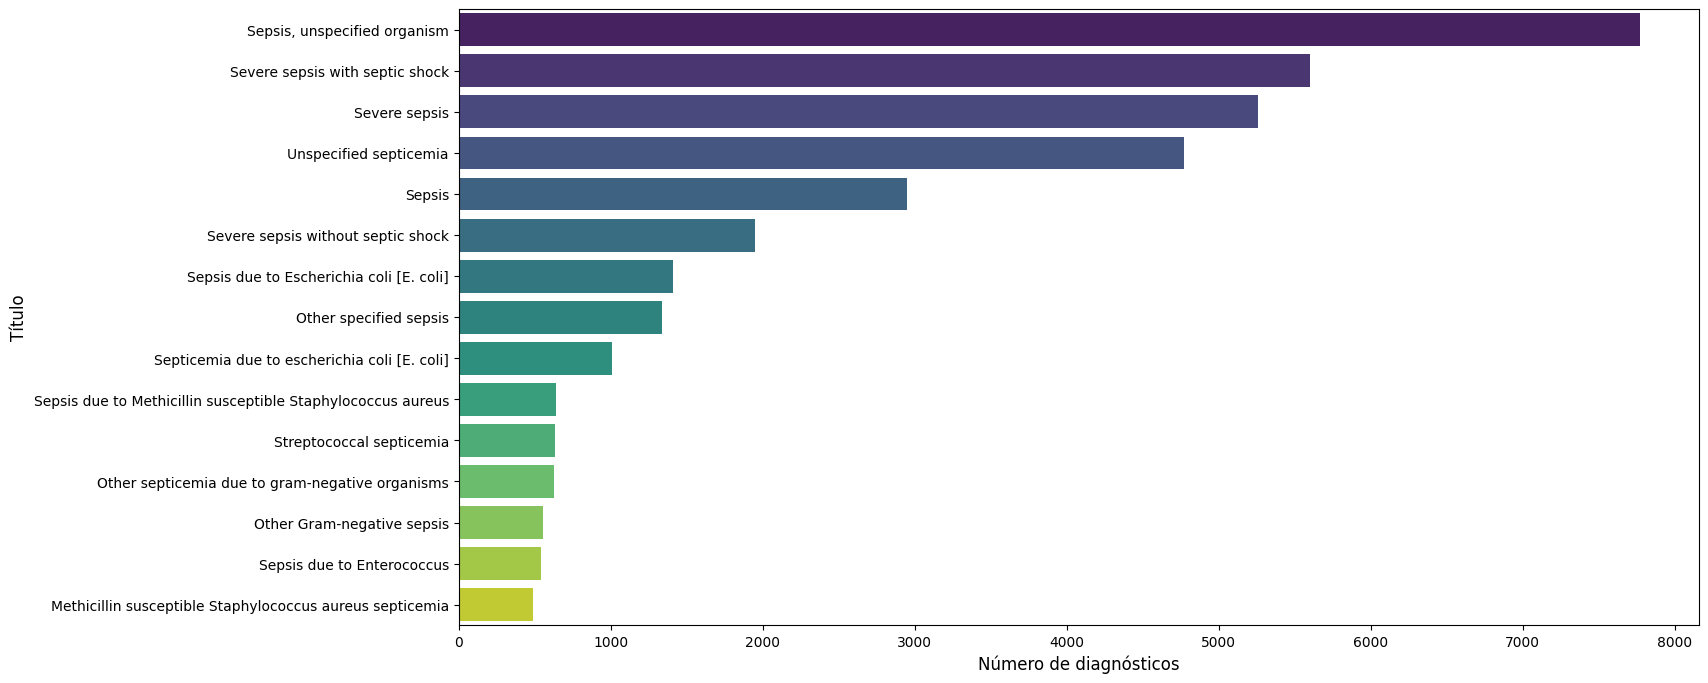

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
codigos_sepsis = d_icd_diagnoses[d_icd_diagnoses['long_title'].str.lower().str.contains('sepsis|septicemia',  na = False)]['icd_code']
qtde_sepsis = diagnoses_icd[diagnoses_icd['icd_code'].isin(codigos_sepsis)].groupby('long_title').size().reset_index(name='num_diagnosticos')

plt.figure(figsize=(16, 8))
sns.barplot(data=qtde_sepsis.nlargest(15, 'num_diagnosticos'), x='num_diagnosticos', y='long_title', palette="viridis")
plt.xlabel('Número de diagnósticos', fontsize = 12)
plt.ylabel('Título', fontsize = 12)
plt.yticks(fontsize = 10)
plt.show()

In [5]:
qtde_sepsis = qtde_sepsis.nlargest(15, 'num_diagnosticos').merge(d_icd_diagnoses, how = 'left', on = 'long_title')
#top_codigos_sepsis = list(qtde_sepsis['icd_code'])
#d_icd_diagnoses[d_icd_diagnoses['icd_code'].isin(top_codigos_sepsis)]
qtde_sepsis

,long_title,num_diagnosticos,icd_code,icd_version
0,"Sepsis, unspecified organism",7770,A419,10
1,Severe sepsis with septic shock,5599,R6521,10
2,Severe sepsis,5257,99592,9
3,Severe sepsis,5257,R652,10
4,Unspecified septicemia,4773,0389,9
5,Sepsis,2953,99591,9
6,Severe sepsis without septic shock,1948,R6520,10
7,Sepsis due to Escherichia coli [E. coli],1413,A4151,10
8,Other specified sepsis,1338,A418,10
9,Other specified sepsis,1338,A4189,10


In [6]:
diagnoses_icd

,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10000032,22595853,1,5723,9,Portal hypertension
1,10000032,22595853,2,78959,9,Other ascites
2,10000032,22595853,3,5715,9,Cirrhosis of liver without mention of alcohol
3,10000032,22595853,4,07070,9,Unspecified viral hepatitis C without hepatic ...
4,10000032,22595853,5,496,9,"Chronic airway obstruction, not elsewhere clas..."
...,...,...,...,...,...,...
6364515,19999987,23865745,7,41401,9,Coronary atherosclerosis of native coronary ar...
6364516,19999987,23865745,8,78039,9,Other convulsions
6364517,19999987,23865745,9,0413,9,Friedländer's bacillus infection in conditions...
6364518,19999987,23865745,10,36846,9,Homonymous bilateral field defects


Usaremos as Sepsis's: 
- A419 → Sepse não especificada
- 0389 → Sepse não especificada com icd_version 9
- R6521 → Sepse grave com choque séptico
- R652 → Sepsis severa(chence de choque) com icd_version 10
- 99592 → Sepsis severa(chence de choque) com icd_version 9
- 4773 → Unspecified septicemia

In [7]:
codigos_sepsis = ['A419', '0389', 'R6521', 'R652', '99592', '4773']
# filtrando agora
diagnoses_icd = diagnoses_icd[diagnoses_icd['icd_code'].isin(codigos_sepsis)]
# Não vamos considerar distinção entre as sepsies em relação à taxa de mortalidade
#diagnoses_icd = diagnoses_icd.reset_index(drop = True).drop(columns = 'long_title')
diagnoses_icd[['icd_code', 'long_title']].value_counts().to_frame().reset_index()

,icd_code,long_title,count
0,A419,"Sepsis, unspecified organism",7770
1,R6521,Severe sepsis with septic shock,5599
2,99592,Severe sepsis,5257
3,0389,Unspecified septicemia,4773


In [8]:
# verificando quais admissões diagnosticadas por sepsis pelo merge
admissions_sepsis = admissions.merge(diagnoses_icd, on=["subject_id", "hadm_id"], how="inner")
admissions_sepsis["admittime"] = pd.to_datetime(admissions_sepsis["admittime"])
admissions_sepsis["deathtime"] = pd.to_datetime(admissions_sepsis["deathtime"])
admissions_sepsis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23399 entries, 0 to 23398
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            23399 non-null  int64         
 1   hadm_id               23399 non-null  int64         
 2   admittime             23399 non-null  datetime64[ns]
 3   dischtime             23399 non-null  object        
 4   deathtime             6521 non-null   datetime64[ns]
 5   admission_type        23399 non-null  object        
 6   admit_provider_id     23399 non-null  object        
 7   admission_location    23399 non-null  object        
 8   discharge_location    23306 non-null  object        
 9   insurance             23175 non-null  object        
 10  language              23273 non-null  object        
 11  marital_status        21706 non-null  object        
 12  race                  23399 non-null  object        
 13  edregtime       

### Filtrando pacientes que morreram em até 30 dias

Pegando apenas pacientes que morreram no intervalo de 30 dias. Essa vai ser a nossa variável alvo nos modelos de ML.
Pacientes com mais de 30 dias entre admissão e morte muito provavelmente não morreram por Sepsis. Para isso, vamos verificar a diferença de tempo entre óbito e admissão.

Um [estudo da UFPE](https://repositorio.ufpe.br/bitstream/123456789/7440/1/arquivo8104_1.pdf?) observou que pacientes que desenvolveram sepse após a admissão hospitalar apresentaram um tempo médio de 3,4 dias até o diagnóstico de sepse, com variação de 1 a 10 dias. O tempo médio de permanência na UTI foi de 11,3 dias para os pacientes que tiveram alta e de 15,7 dias para aqueles que evoluíram para óbito. Então acreditamos que 30 dias seja um valor aceitável.

In [9]:
def verificar_morte(row):
    # pessoas que não morreram
    if pd.isna(row['deathtime']):
        return 'Sobrevivente'
    # morreram em mais de 30 dias
    # aqui, entenda 0 como: "A uti foi capaz de conter a sepsis, mas não por outra doença"
    elif (row['deathtime'] - row['admittime']).days > 30:
        return 'Sobrevivente'
    # morreram em menos de 30 dias
    else:
        return 'Óbito'


admissions_sepsis['Morte_em_30_dias'] = admissions_sepsis.apply(verificar_morte, axis = 1)
admissions_sepsis.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version,long_title,Morte_em_30_dias
0,10001401,27060146,2131-10-01 01:33:00,2131-10-05 15:45:00,NaT,OBSERVATION ADMIT,P67ZVR,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,...,MARRIED,WHITE,2131-09-30 16:47:00,2131-10-01 02:24:00,0,2,A419,10,"Sepsis, unspecified organism",Sobrevivente
1,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,2134-12-06 12:54:00,URGENT,P67ATB,TRANSFER FROM HOSPITAL,DIED,Medicare,...,SINGLE,WHITE,NaN,NaN,1,1,A419,10,"Sepsis, unspecified organism",Óbito
2,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,2134-12-06 12:54:00,URGENT,P67ATB,TRANSFER FROM HOSPITAL,DIED,Medicare,...,SINGLE,WHITE,NaN,NaN,1,6,R6521,10,Severe sepsis with septic shock,Óbito
3,10002013,24848509,2162-07-08 00:08:00,2162-07-09 18:06:00,NaT,EW EMER.,P87IIY,EMERGENCY ROOM,HOME,Medicare,...,SINGLE,WHITE,2162-07-07 19:40:00,2162-07-08 01:45:00,0,1,0389,9,Unspecified septicemia,Sobrevivente
4,10002013,24848509,2162-07-08 00:08:00,2162-07-09 18:06:00,NaT,EW EMER.,P87IIY,EMERGENCY ROOM,HOME,Medicare,...,SINGLE,WHITE,2162-07-07 19:40:00,2162-07-08 01:45:00,0,5,99592,9,Severe sepsis,Sobrevivente


Analisando a qtde de mortos por tipo de Sepsis

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\4247259919.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


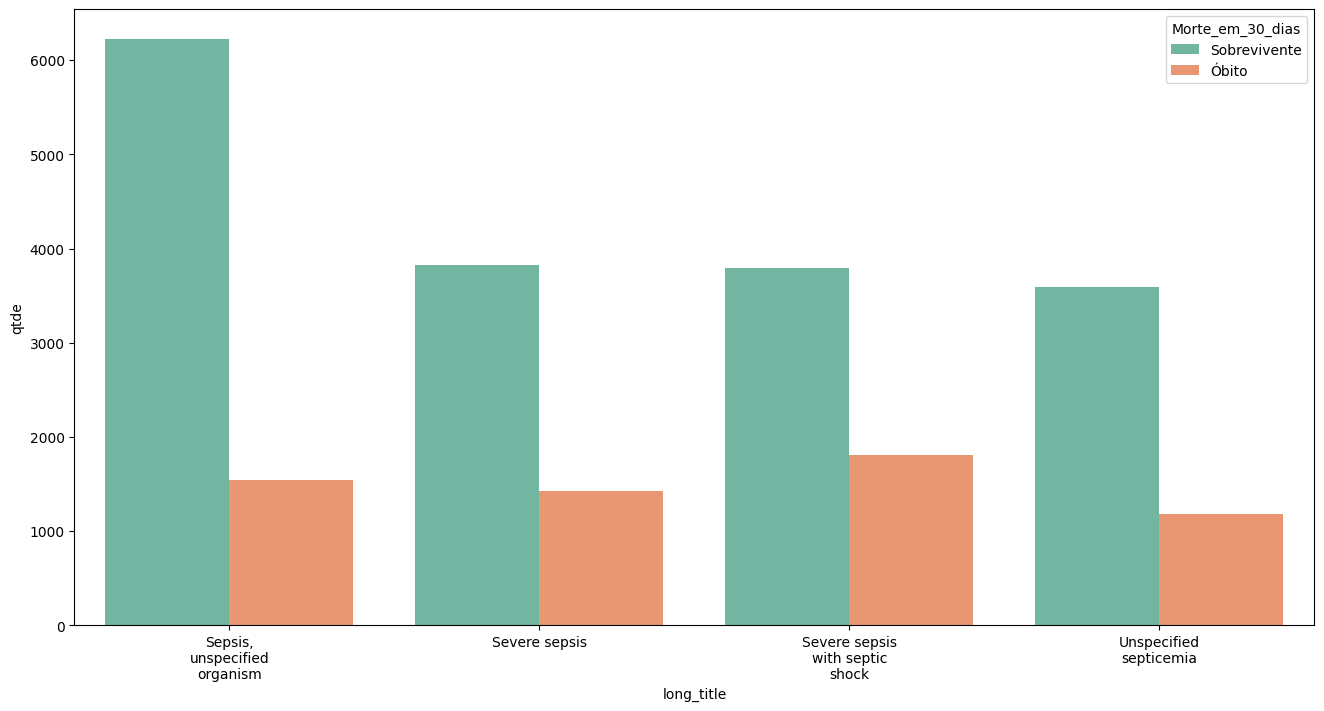

In [10]:
import textwrap
analisar_mortes = admissions_sepsis[['Morte_em_30_dias', 'long_title']]
analisar_mortes = analisar_mortes.groupby(['long_title', 'Morte_em_30_dias']).size().reset_index(name = 'qtde')
fig, ax = plt.subplots(figsize = (16, 8))
wrapped_labels = [textwrap.fill(label, width=15) for label in analisar_mortes['long_title'].unique()]
sns.barplot(data = analisar_mortes, x = 'long_title', y = 'qtde', hue = 'Morte_em_30_dias', palette= 'Set2', ax = ax)
ax.set_xticklabels(wrapped_labels)
plt.show()

Observe que evidentemente Sepsis Severas e com Choque tem um índice de mortalidade maior. Além disso, Septicemia não especificada também apresenta um valor bem alto de mortalidade, isso ocorre porque a "Septicemia" é um quadro um pouco mais agravado de Sepsis, ocasionalmente acompanhada de liberação de toxinas. 

Também observe que temos um grande desbalanceamento entre as classes, que será contornado futuramente.

Antes de dropamos as colunas que não iremos utilizar pois não servem especificamente para o nosso estudo, vamos avaliar algumas distribuições:

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\1780597595.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  else: ax.set_xticklabels(ax.get_xticklabels(), ha='right')
C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\1780597595.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  else: ax.set_xticklabels(ax.get_xticklabels(), ha='right')
C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\1780597595.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([textwrap.fill(label.get_text(), width=10) for label in ax.get_xticklabels()])


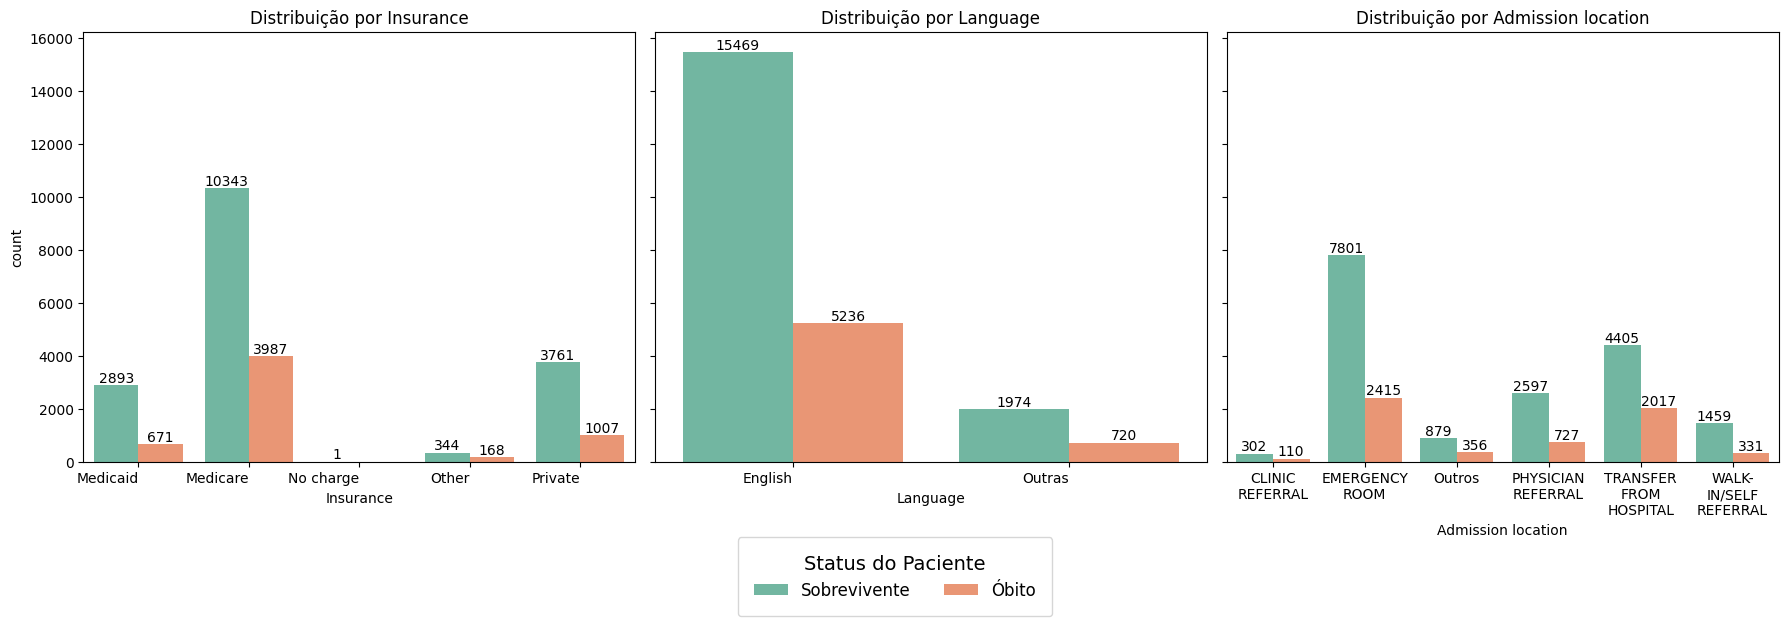

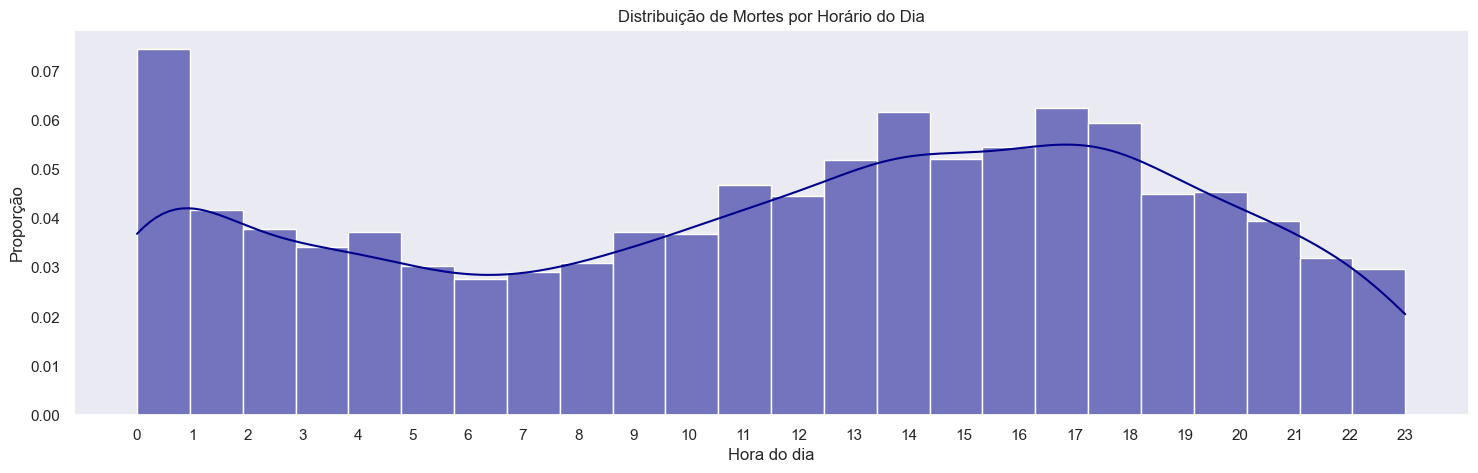

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

categ_drop_est = ['insurance', 'language', 'admission_location']
admissions_sepsis = admissions_sepsis.copy()

# Agrupar idiomas que não sejam "English", porque inglês tem bem mais pacientes
admissions_sepsis['language'] = admissions_sepsis['language'].apply(lambda x: x if x == 'English' else 'Outras')

admissions_sepsis['admission_location'] = admissions_sepsis['admission_location'].apply(
    lambda x: x if x in ['PHYSICIAN REFERRAL', 'EMERGENCY ROOM', 'TRANSFER FROM HOSPITAL','CLINIC REFERRAL', 'WALK-IN/SELF REFERRAL'] else 'Outros'
)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, col in enumerate(categ_drop_est):
    df_plot = admissions_sepsis.groupby([col, 'Morte_em_30_dias']).size().reset_index(name='count')

    ax = sns.barplot(
        data=df_plot,
        x=col,
        y='count',
        hue='Morte_em_30_dias',
        palette='Set2',
        ax=axes[i],
    )

    # Adicionando rótulos nas barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=10)

    ax.set_xlabel(col.capitalize().replace('_', ' '))
    if i == 2:
        ax.set_xticklabels([textwrap.fill(label.get_text(), width=10) for label in ax.get_xticklabels()])
    else: ax.set_xticklabels(ax.get_xticklabels(), ha='right')

    ax.set_title(f"Distribuição por {col.capitalize().replace('_', ' ')}")
    ax.legend().set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Sobrevivente', 'Óbito'], title="Status do Paciente", loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize = 12, title_fontsize = 14, borderpad = 1)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

# distribuição de mortes por horário
plt.figure(figsize=(18, 5)) 

admissions_sepsis['hour_of_death'] = pd.to_datetime(admissions_sepsis['deathtime']).dt.hour

sns.set_theme(style="darkgrid")
sns.histplot(
    admissions_sepsis['hour_of_death'].dropna(),
    bins=24,
    kde=True,
    color='darkblue',
    stat="density"
)

plt.xlabel("Hora do dia")
plt.ylabel("Proporção")
plt.title("Distribuição de Mortes por Horário do Dia")
plt.xticks(range(0, 24))
plt.grid()

plt.show()


- Distribuição pelo tipo de seguro(`insurance`):
    - É importante para avaliar se há diferenciação no atendimento/cuidado por causa do plano de saúde, aqui no Brasil acho que isso reflete bastante, mas não vai ser uma das nossas variáveis
    - Veja que no caso do hospital em Israel, não tem tanta diferença assim.

- Distribuição por Idioma (`language`)
    - Para nossa realidade, não seria interessante avaliar, mas no caso da MIMIC, poderia ser um idicador de diferenciação(ex: xenofobia)
    - Mortalidade ligeiramente maior para "Outros", sugerindo possível impacto de barreiras linguísticas no atendimento.

- Distribuição por Local de Admissão (`admission_location`)
    - A maioria dos pacientes vem do **Pronto-Socorro** ou por **Transferência de Outros Hospitais**.
    - Pacientes transferidos apresentam maior mortalidade, sugerindo chegada em estado mais crítico.
    - **Entrada espontânea (Walk-in)** tem menor taxa de óbitos, indicando casos menos graves.
    - Não vai ser uma variável porque acreditamos ser totalmente distinto ao modelo do Brasil

- Distribuição de Mortes por Horário do Dia(`deathtime`)
    - É interessante para alertar o hospital sobre horários críticos e ajustar os plantões, mas varia muito de lugar para lugar
    - No caso da MIMIC, vemos
        - **Pico de mortes à meia-noite (00h)**, possivelmente relacionado a mudanças de plantão.
        - Menor mortalidade entre **2h e 6h**.

In [12]:
admissions_sepsis = admissions_sepsis[['subject_id', 'hadm_id', 'admittime', 'deathtime', 'admission_type', 'race', 'Morte_em_30_dias']]
admissions_sepsis.head()

,subject_id,hadm_id,admittime,deathtime,admission_type,race,Morte_em_30_dias
0,10001401,27060146,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente
1,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,URGENT,WHITE,Óbito
2,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,URGENT,WHITE,Óbito
3,10002013,24848509,2162-07-08 00:08:00,NaT,EW EMER.,WHITE,Sobrevivente
4,10002013,24848509,2162-07-08 00:08:00,NaT,EW EMER.,WHITE,Sobrevivente


### Acoplando mais informações dos pacientes

In [13]:
import pandas as pd

patients = pd.read_csv('C:\\Users\\Felipe 1\\Downloads\\mimic-iv-3.0\\mimic-iv-3.0\\hosp\\patients.csv\\patients.csv')
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


Vale uma explicação: As datas e idades são todas fictícias;
- `anchor_age`: Idade do paciente na admissão inicial
- `anchor_year`: Ano de referência da internação inicial
- `dod`: Data do óbito
- `anchor_year_group`: Faixa de tempo da admissão inicial


In [14]:
patients = patients[['subject_id', 'gender', 'anchor_age']]
patients_and_admission = admissions_sepsis.join(patients.set_index('subject_id'), on = 'subject_id')
patients_and_admission.head()

,subject_id,hadm_id,admittime,deathtime,admission_type,race,Morte_em_30_dias,gender,anchor_age
0,10001401,27060146,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89
1,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,URGENT,WHITE,Óbito,M,73
2,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,URGENT,WHITE,Óbito,M,73
3,10002013,24848509,2162-07-08 00:08:00,NaT,EW EMER.,WHITE,Sobrevivente,F,53
4,10002013,24848509,2162-07-08 00:08:00,NaT,EW EMER.,WHITE,Sobrevivente,F,53


### Verificando dados de exames laboratoriais do paciente

In [15]:
# labevents é um dataframe muito grande, tive que transformar em parquet
colunas_desejadas = ['subject_id', 'hadm_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom', 'flag']

# Carregar o arquivo Parquet apenas com as colunas desejadas
labevents = pd.read_parquet("C:\\Users\\Felipe 1\\Downloads\\mimic-iv-3.0\\mimic-iv-3.0\\hosp\\labevents.csv\\labevents.parquet",
                            columns=colunas_desejadas, engine="fastparquet")
labevents.head()

,subject_id,hadm_id,itemid,charttime,value,valuenum,valueuom,flag
0,10000032,NaN,50931,2180-03-23 11:51:00,___,95.0,mg/dL,None
1,10000032,NaN,51071,2180-03-23 11:51:00,NEG,NaN,None,None
2,10000032,NaN,51074,2180-03-23 11:51:00,NEG,NaN,None,None
3,10000032,NaN,51075,2180-03-23 11:51:00,NEG,NaN,None,None
4,10000032,NaN,51079,2180-03-23 11:51:00,NEG,NaN,None,None


**Filtrando exames:**

Aqui eu tinha 2 alternativas:
- Exames utilizados nos artigos que são importantes para a Sepse(em 24h de admissão), mas isso era recomendado um parecer médico prévio
- Pegar todos os exames, aferir quais tem uma correlação razoável com a `Morte_em_30_dias`

Por motivos práticos, escolhi a segunda opção, mas no fim do trabalho um médico avaliou as variáveis que usei com base nisso e foi satisfatório.


In [16]:
# fazendo merge de todos os exames com admissions
patient_lab_and_admission = pd.merge(labevents, patients_and_admission, how='right', on=['subject_id','hadm_id'])

patient_lab_and_admission['charttime'] = pd.to_datetime(patient_lab_and_admission['charttime'])
patient_lab_and_admission['admittime'] = pd.to_datetime(patient_lab_and_admission['admittime'])
# Aqui pegando apenas eventos entre charttime admittime + 30 dias

mask = (patient_lab_and_admission['charttime'] >= patient_lab_and_admission['admittime']) & \
       (patient_lab_and_admission['charttime'] <= patient_lab_and_admission['admittime'] + pd.Timedelta(days=30))

patient_lab_and_admission = patient_lab_and_admission[mask]

patient_lab_and_admission.head()

,subject_id,hadm_id,itemid,charttime,value,valuenum,valueuom,flag,admittime,deathtime,admission_type,race,Morte_em_30_dias,gender,anchor_age
50,10001401,27060146.0,51221.0,2131-10-01 10:40:00,24.5,24.5,%,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89
51,10001401,27060146.0,51222.0,2131-10-01 10:40:00,7.5,7.5,g/dL,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89
52,10001401,27060146.0,51248.0,2131-10-01 10:40:00,27.7,27.7,pg,None,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89
53,10001401,27060146.0,51249.0,2131-10-01 10:40:00,30.6,30.6,g/dL,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89
54,10001401,27060146.0,51250.0,2131-10-01 10:40:00,90,90.0,fL,None,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89


Acoplando os nomes dos exames no nosso dataframe(não que isso me ajude a entender, porque não sou médico haha)

In [17]:
d_labitems = pd.read_csv("C:\\Users\\Felipe 1\\Downloads\\mimic-iv-3.0\\mimic-iv-3.0\\hosp\\d_labitems.csv\\d_labitems.csv")
exames_label = d_labitems.drop(columns= 'category')
exames_label

,itemid,label,fluid
0,50801,Alveolar-arterial Gradient,Blood
1,50802,Base Excess,Blood
2,50803,"Calculated Bicarbonate, Whole Blood",Blood
3,50804,Calculated Total CO2,Blood
4,50805,Carboxyhemoglobin,Blood
...,...,...,...
1645,53186,Rapid COVID-19 PCR,Other Body Fluid
1646,53187,PAN,Stool
1647,53188,Lymphocytes,Blood
1648,53189,Platelet Count,Blood


In [18]:
patient_lab_and_admission = patient_lab_and_admission.merge(exames_label[['itemid', 'label']], on = 'itemid', how = 'left')
patient_lab_and_admission.head()

,subject_id,hadm_id,itemid,charttime,value,valuenum,valueuom,flag,admittime,deathtime,admission_type,race,Morte_em_30_dias,gender,anchor_age,label
0,10001401,27060146.0,51221.0,2131-10-01 10:40:00,24.5,24.5,%,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,Hematocrit
1,10001401,27060146.0,51222.0,2131-10-01 10:40:00,7.5,7.5,g/dL,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,Hemoglobin
2,10001401,27060146.0,51248.0,2131-10-01 10:40:00,27.7,27.7,pg,None,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,MCH
3,10001401,27060146.0,51249.0,2131-10-01 10:40:00,30.6,30.6,g/dL,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,MCHC
4,10001401,27060146.0,51250.0,2131-10-01 10:40:00,90,90.0,fL,None,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,MCV


Vamos deixar apenas exames que a maioria dos pacientes fizeram, aqui assumimos que exames que a minoria dos pacientes não tem uma relação direta com a Sepsis. Para ver qual percentagem é a ideal, vamos avaliar a distribuição. 

Entretanto, temos um "Trade-off" aqui, se pergarmos apenas exames que a grande maioria dos pacientes fez, talvez possamos pegar pouquíssimos exames, então temos que equilibrar a quantidade de exames com a percentagem de pacientes que realizaram cada exame.

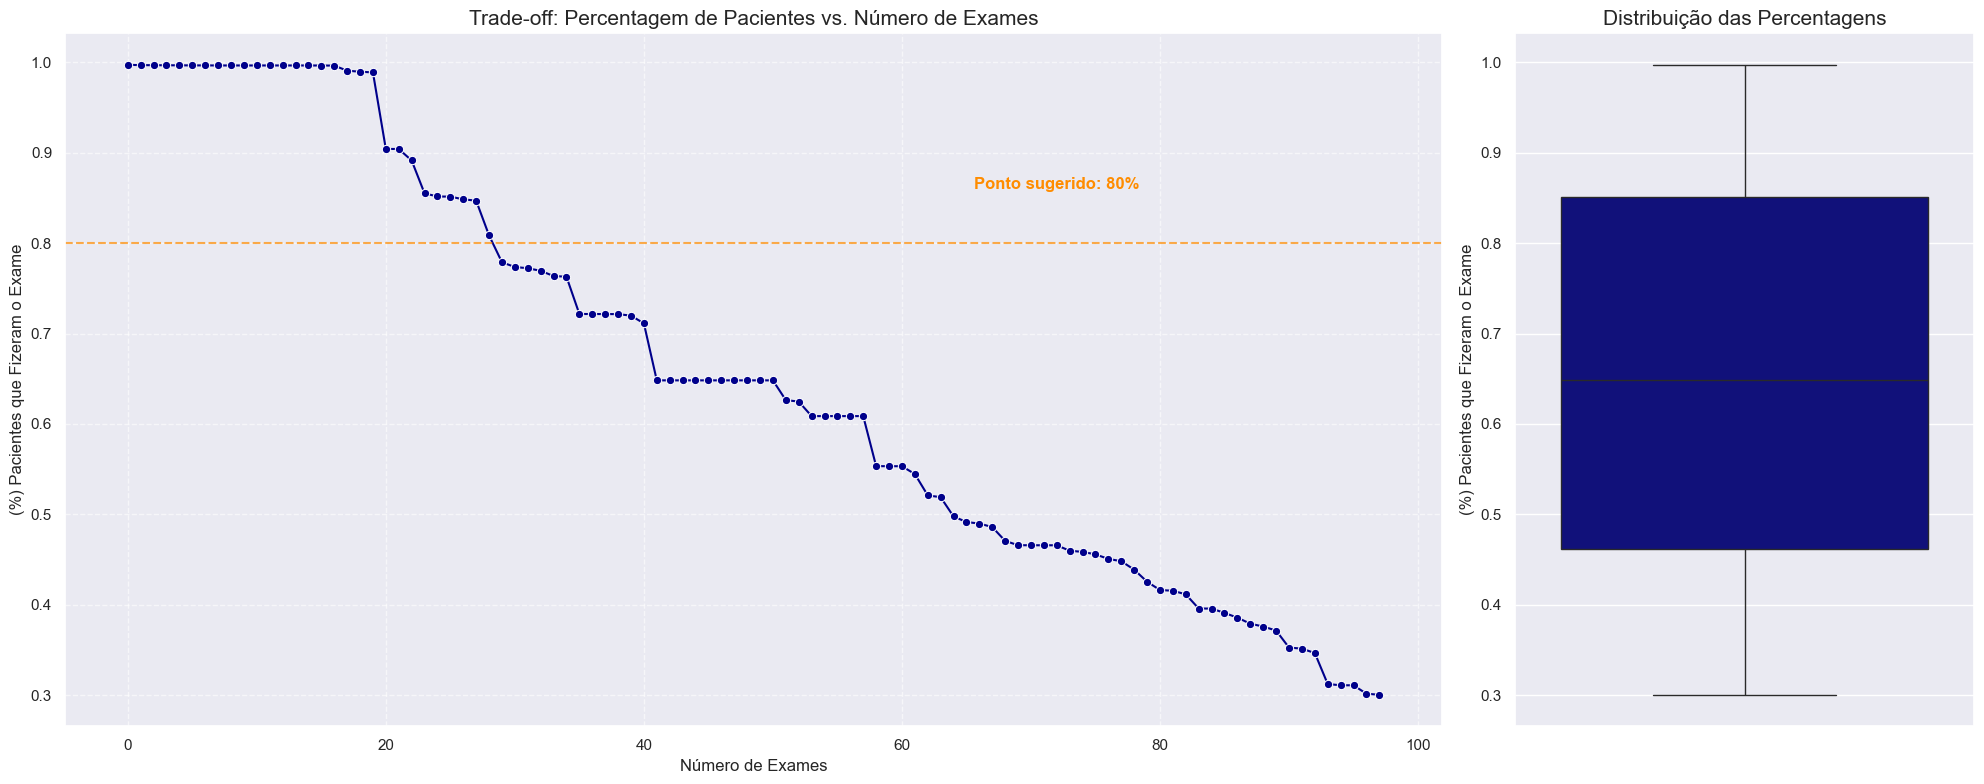

In [19]:
# Contar a percentagem de pacientes que fizeram cada exame
exam_counts = patient_lab_and_admission.groupby("label")["subject_id"].nunique().reset_index()
exam_counts.columns = ["label", "num_pacientes"]
exam_counts["percent_pacientes"] = exam_counts["num_pacientes"] / patient_lab_and_admission["subject_id"].nunique()

exam_counts = exam_counts[exam_counts['percent_pacientes'] > 0.3]

fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [3, 1]})

# Distr
sns.lineplot(ax=axes[0], y=sorted(exam_counts["percent_pacientes"], reverse=True), 
             x=range(len(exam_counts)), marker="o", color="darkblue", errorbar=None)
axes[0].set_ylabel("(%) Pacientes que Fizeram o Exame", fontsize=12)
axes[0].set_xlabel("Número de Exames", fontsize=12)
axes[0].set_title("Trade-off: Percentagem de Pacientes vs. Número de Exames", fontsize=15)
axes[0].axhline(0.80, linestyle="--", color="darkorange", alpha=0.7)
axes[0].text(len(exam_counts) * 0.8, 0.86, f"Ponto sugerido: {0.80*100:.0f}%", color="darkorange", weight = "bold", fontsize=12, ha='right')
axes[0].grid(True, linestyle="--", alpha=0.6)

# Boxplot
sns.boxplot(ax=axes[1], y=exam_counts["percent_pacientes"], color="darkblue")
axes[1].set_title("Distribuição das Percentagens", fontsize=15)
axes[1].set_ylabel("(%) Pacientes que Fizeram o Exame", fontsize=12)
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()



Observe que, se escolhessemos um valor perto de 100%(somente exames que todos os pacientes realizaram), teríamos cerca de 17 exames(o que é um número pequeno de parâmetros para caracterizar a Sepsis).

Pelo gráfico, acreditamos que um valor que equilibra a porcentagem de pacientes que fizeram o exame e um número razoável de exames(31) seria 80%.

Algo interessante é que a quantidade de exames varia de maneira próxima a uma "escada", sugerindo possivelmente algum tipo de procedimento médico, a maioria dos pacientes fazem determinados exames, se o quadro se agrava, os pacientes fazem exames mais específicos. 

Assim, seria interessante, se validada essa hipótese, estimar a gravidade do paciente através dos exames que ele realizou(até qual patamar da "escada" ele subiu: patamares mais baixos indicam maior gravidade)

In [20]:
exames_mais_comuns = exam_counts[exam_counts["percent_pacientes"] >= 0.80]

patient_lab_and_admission = patient_lab_and_admission[
    patient_lab_and_admission["label"].isin(exames_mais_comuns['label'])
]

patient_lab_and_admission.head()

,subject_id,hadm_id,itemid,charttime,value,valuenum,valueuom,flag,admittime,deathtime,admission_type,race,Morte_em_30_dias,gender,anchor_age,label
0,10001401,27060146.0,51221.0,2131-10-01 10:40:00,24.5,24.5,%,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,Hematocrit
1,10001401,27060146.0,51222.0,2131-10-01 10:40:00,7.5,7.5,g/dL,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,Hemoglobin
2,10001401,27060146.0,51248.0,2131-10-01 10:40:00,27.7,27.7,pg,None,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,MCH
3,10001401,27060146.0,51249.0,2131-10-01 10:40:00,30.6,30.6,g/dL,abnormal,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,MCHC
4,10001401,27060146.0,51250.0,2131-10-01 10:40:00,90,90.0,fL,None,2131-10-01 01:33:00,NaT,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,MCV


De todas as possíveis abordagens para a escolha de features para o nosso modelo, é interessante avaliar os picos de máx e mín dos exames que o paciente realizou durante a internação, a Sepsis é caracterizada normalmente por picos em temperatura, frequência respiratória, pressão arterial, etc, então estudar os máximos e mínimos em exames é uma maneira razoável de compreender o quadro do paciente. [Sepse e choque séptico](https://www.msdmanuals.com/pt/casa/infec%C3%A7%C3%B5es/bacteremia-sepse-e-choque-s%C3%A9ptico/sepse-e-choque-s%C3%A9ptico#Sintomas_v784709_pt)

Essa abordagem foi a mesma utilizada por esse [artigo](https://www.medintensiva.org/en-machine-learning-models-for-prediction-sepsis-articulo-S2173572722003101)

Agora que temos todos os dados de exames dos pacientes durante a internação, vamos avaliar os máximos e mínimos de cada paciente por exame, uma vez que variações de valores indicam melhora ou piora do paciente.

In [21]:

exame_patients = patient_lab_and_admission.groupby(['subject_id', 'label'])['valuenum'].agg(['min', 'max']).reset_index()
exame_patients = exame_patients.pivot(index= 'subject_id', columns= 'label', values = ['min', 'max'])
exame_patients.columns = [f"{exam.lower().replace(' ', '_')}_{stat}" for stat, exam in exame_patients.columns]
exame_patients.rename(columns = {'calcium,_total_min': 'calcium_total_min','calcium,_total_max': 'calcium_total_max'}, inplace = True)
exame_patients = exame_patients[sorted(exame_patients.columns)]
exame_patients.reset_index(inplace=True)
exame_patients.head()

,subject_id,alanine_aminotransferase_(alt)_max,alanine_aminotransferase_(alt)_min,alkaline_phosphatase_max,alkaline_phosphatase_min,anion_gap_max,anion_gap_min,asparate_aminotransferase_(ast)_max,asparate_aminotransferase_(ast)_min,bicarbonate_max,...,rdw_max,rdw_min,red_blood_cells_max,red_blood_cells_min,sodium_max,sodium_min,urea_nitrogen_max,urea_nitrogen_min,white_blood_cells_max,white_blood_cells_min
0,10001401,NaN,NaN,NaN,NaN,19.0,13.0,NaN,NaN,26.0,...,15.7,14.6,3.15,2.64,144.0,137.0,24.0,8.0,18.8,6.9
1,10001843,90.0,77.0,569.0,545.0,16.0,11.0,196.0,136.0,29.0,...,22.4,22.0,3.42,3.24,139.0,137.0,33.0,27.0,13.8,10.4
2,10002013,25.0,14.0,130.0,50.0,18.0,13.0,29.0,17.0,29.0,...,12.9,11.9,3.60,2.85,143.0,136.0,25.0,12.0,15.0,7.0
3,10002428,66.0,44.0,163.0,70.0,21.0,6.0,102.0,52.0,39.0,...,14.7,12.8,3.75,2.47,144.0,128.0,57.0,13.0,33.4,7.1
4,10003019,43.0,35.0,123.0,114.0,14.0,9.0,20.0,13.0,26.0,...,22.0,18.7,2.99,2.53,140.0,133.0,24.0,15.0,30.2,0.2


In [22]:
# ajustando a nossa fonte
colunas_desejadas = ['subject_id', 'hadm_id', 'itemid', 'charttime', 'admittime', 'admission_type', 'race', 'Morte_em_30_dias', 'gender', 'anchor_age']
patients_geral = patient_lab_and_admission[colunas_desejadas].drop_duplicates(subset= 'subject_id').merge(exame_patients, on = 'subject_id')
patients_geral.head()

,subject_id,hadm_id,itemid,charttime,admittime,admission_type,race,Morte_em_30_dias,gender,anchor_age,...,rdw_max,rdw_min,red_blood_cells_max,red_blood_cells_min,sodium_max,sodium_min,urea_nitrogen_max,urea_nitrogen_min,white_blood_cells_max,white_blood_cells_min
0,10001401,27060146.0,51221.0,2131-10-01 10:40:00,2131-10-01 01:33:00,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,...,15.7,14.6,3.15,2.64,144.0,137.0,24.0,8.0,18.8,6.9
1,10001843,26133978.0,50861.0,2134-12-05 09:08:00,2134-12-05 00:10:00,URGENT,WHITE,Óbito,M,73,...,22.4,22.0,3.42,3.24,139.0,137.0,33.0,27.0,13.8,10.4
2,10002013,24848509.0,50868.0,2162-07-08 06:23:00,2162-07-08 00:08:00,EW EMER.,WHITE,Sobrevivente,F,53,...,12.9,11.9,3.60,2.85,143.0,136.0,25.0,12.0,15.0,7.0
3,10002428,28662225.0,50868.0,2156-04-12 19:24:00,2156-04-12 14:16:00,EW EMER.,WHITE,Sobrevivente,F,80,...,14.7,12.8,3.75,2.47,144.0,128.0,57.0,13.0,33.4,7.1
4,10003019,22774359.0,50868.0,2175-10-08 20:00:00,2175-10-08 13:56:00,EW EMER.,WHITE,Sobrevivente,M,69,...,22.0,18.7,2.99,2.53,140.0,133.0,24.0,15.0,30.2,0.2


### Avaliando os sinais vitais e monitoramento clínico do paciente(chartevents)
Vamos fazer a mesma análise que fizemos para os exames laboratóriais

In [23]:
chartevents = pd.read_parquet('chartevents_30_dias.parquet', engine = 'fastparquet')
chartevents.head()

,subject_id,charttime,itemid,valuenum,admittime
0,10000032,2180-07-23 12:36:00,226512,39.400002,2180-06-26 18:27:00
1,10000032,2180-07-23 12:36:00,226512,39.400002,2180-07-23 12:35:00
2,10000032,2180-07-23 12:36:00,226707,60.000000,2180-06-26 18:27:00
3,10000032,2180-07-23 12:36:00,226707,60.000000,2180-07-23 12:35:00
4,10000032,2180-07-23 12:36:00,226730,152.000000,2180-06-26 18:27:00


Deixando somente pacientes em Sepsis

In [24]:
chartevents = chartevents[chartevents['subject_id'].isin(list(patients_geral['subject_id'].unique()))]

Removendo sinais vitais não realizados por 60 por cento dos pacientes(vamos fazer uma análise mais detalhada futuramente)

In [25]:
# chunksize = 1_000_000
# admissions_reduzido = admissions[['subject_id', 'admittime']].copy()

# print(chartevents.shape)

# chartevents_processado = pd.DataFrame()

# num_chunks = (len(chartevents) // chunksize) + 1

# for i in range(0, len(chartevents), chunksize):
    
#     print(f"Processando chunk {i // chunksize + 1} de {num_chunks}...")


#     chunk = chartevents.iloc[i:i + chunksize].copy()

#     chunk = chunk.merge(admissions_reduzido, on="subject_id", how="left")

#     chunk['charttime'] = pd.to_datetime(chunk['charttime'])
#     chunk['admittime'] = pd.to_datetime(chunk['admittime'])


#     mask = (chunk['charttime'] >= chunk['admittime']) & \
#            (chunk['charttime'] <= chunk['admittime'] + pd.Timedelta(days=30))

#     chunk_filtrado = chunk[mask]

#     chartevents_processado = pd.concat([chartevents_processado, chunk_filtrado], ignore_index=True)


# chartevents = chartevents_processado

# print(chartevents.shape)

# chartevents.to_parquet('chartevents_30_dias.parquet', engine= 'fastparquet', index= False)




In [26]:
total_pacientes = chartevents['subject_id'].nunique()

exam_counts = chartevents.groupby('itemid')['subject_id'].nunique().reset_index()
exam_counts.columns = ['itemid', 'num_pacientes']
exam_counts['percent_pacientes'] = exam_counts['num_pacientes'] / total_pacientes

exames_mais_comuns = exam_counts.loc[exam_counts['percent_pacientes'] >= 0.6, 'itemid']

chartevents = chartevents[chartevents['itemid'].isin(exames_mais_comuns)]

chartevents

,subject_id,charttime,itemid,valuenum,admittime
8963,10001843,2134-12-06 08:00:00,223835,40.000000,2134-12-05 00:10:00
8964,10001843,2134-12-06 08:00:00,220339,5.000000,2134-12-05 00:10:00
8965,10001843,2134-12-06 08:00:00,224692,NaN,2134-12-05 00:10:00
8967,10001843,2134-12-06 08:00:00,224735,NaN,2134-12-05 00:10:00
8968,10001843,2134-12-06 08:00:00,224865,NaN,2134-12-05 00:10:00
...,...,...,...,...,...
446880922,19997886,2186-12-08 02:36:00,227442,2.800000,2186-11-12 07:10:00
446880923,19997886,2186-12-08 03:13:00,220228,8.600000,2186-11-12 07:10:00
446880924,19997886,2186-12-08 03:13:00,220545,27.200001,2186-11-12 07:10:00
446880925,19997886,2186-12-08 03:13:00,220546,13.500000,2186-11-12 07:10:00


In [27]:
chartevents.drop(columns = 'admittime', inplace= True)
# carregando o dataframe com o nome dos sinais
d_items = pd.read_csv("C:\\Users\\Felipe 1\\Downloads\\mimic-iv-3.0\\mimic-iv-3.0\\icu\\d_items.csv\\d_items.csv")
d_items = d_items[d_items['linksto'] == 'chartevents'][['itemid', 'label', 'abbreviation']]
chartevents = chartevents.merge(d_items, on = 'itemid', how = 'left')
chartevents

,subject_id,charttime,itemid,valuenum,label,abbreviation
0,10001843,2134-12-06 08:00:00,223835,40.000000,Inspired O2 Fraction,FiO2
1,10001843,2134-12-06 08:00:00,220339,5.000000,PEEP set,PEEP set
2,10001843,2134-12-06 08:00:00,224692,NaN,Flow Pattern,Flow Pattern
3,10001843,2134-12-06 08:00:00,224735,NaN,Flow Rate (variable/fixed),Flow Rate (variable/fixed)
4,10001843,2134-12-06 08:00:00,224865,NaN,Flow Sensitivity,Flow Sensitivity
...,...,...,...,...,...,...
107201068,19997886,2186-12-08 02:36:00,227442,2.800000,Potassium (serum),Potassium (serum)
107201069,19997886,2186-12-08 03:13:00,220228,8.600000,Hemoglobin,Hemoglobin
107201070,19997886,2186-12-08 03:13:00,220545,27.200001,Hematocrit (serum),Hematocrit (serum)
107201071,19997886,2186-12-08 03:13:00,220546,13.500000,WBC,WBC


Temos 228 exames de sinais vitais

In [28]:
d_items[d_items['itemid'].isin(chartevents['itemid'].unique())].reset_index(drop = True)

,itemid,label,abbreviation
0,220001,Problem List,Problem List
1,220045,Heart Rate,HR
2,220046,Heart rate Alarm - High,HR Alarm - High
3,220047,Heart Rate Alarm - Low,HR Alarm - Low
4,220048,Heart Rhythm,Heart Rhythm
...,...,...,...
234,228868,Assistance,Assistance
235,228879,Education Readiness/Motivation,Education Readiness/Motivation
236,228880,Education Existing Knowledge,Education Existing Knowledge
237,229321,Activity / Mobility (JH-HLM),Activity / Mobility (JH-HLM)


Verificando como a distribuição dos sinais vitais está e evitar termos muitas variáveis vazias. Lembrando que removemos os exames que não tinham em menos de 60% das pessoas

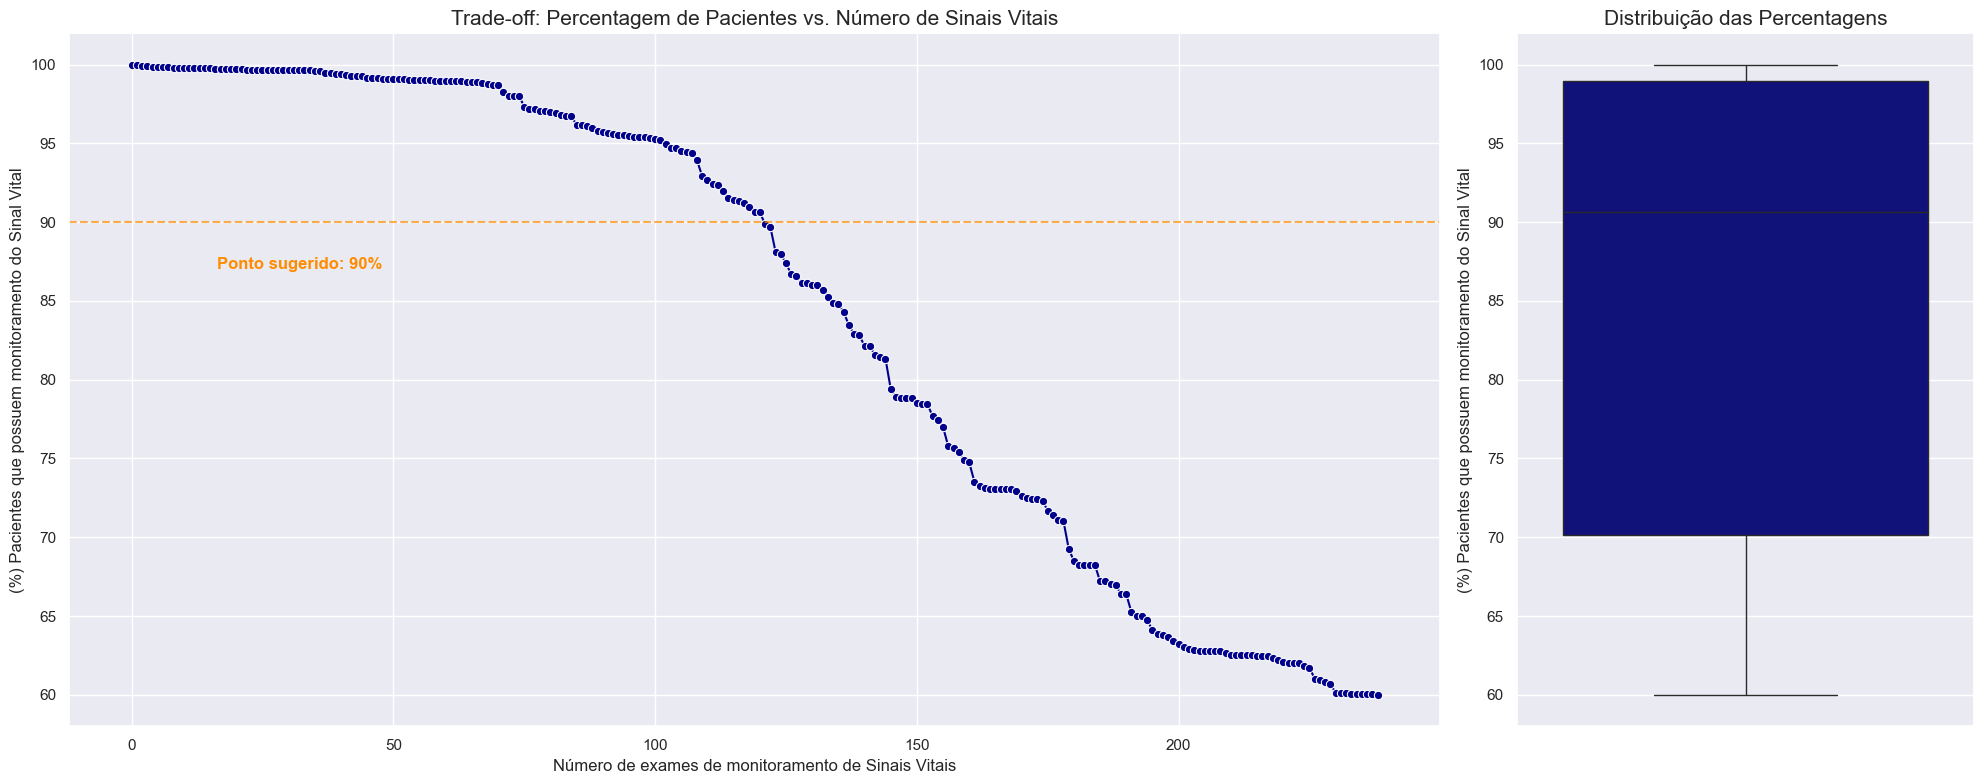

In [ ]:
# Contar a percentagem de pacientes que possuem cada sinal vital registrado
sinais_vitais = chartevents.groupby("label")["subject_id"].nunique().reset_index()
sinais_vitais.columns = ["label", "num_pacientes"]

total_pacientes = chartevents["subject_id"].nunique()
sinais_vitais["percentual_pacientes"] = (sinais_vitais["num_pacientes"] / total_pacientes) * 100


fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw= {'width_ratios': [3, 1]})

sns.lineplot(ax = axes[0], y=sorted(sinais_vitais["percentual_pacientes"], reverse=True), x=range(len(sinais_vitais)), marker="o", color="darkblue")

axes[0].set_ylabel("(%) Pacientes que possuem monitoramento do Sinal Vital", fontsize=12)
axes[0].set_xlabel("Número de exames de monitoramento de Sinais Vitais", fontsize=12)
axes[0].set_title("Trade-off: Percentagem de Pacientes vs. Número de Sinais Vitais", fontsize=15)


axes[0].axhline(90, linestyle="--", color="darkorange", alpha=0.7)
axes[0].text(len(sinais_vitais) * 0.2, 90 - 3, f"Ponto sugerido: {90:.0f}%", color="darkorange", weight = "bold", fontsize=12, ha='right')

# Boxplot
sns.boxplot(ax=axes[1], y=sinais_vitais["percentual_pacientes"], color="darkblue")
axes[1].set_title("Distribuição das Percentagens", fontsize=15)
axes[1].set_ylabel("(%) Pacientes que possuem monitoramento do Sinal Vital", fontsize=12)
axes[1].set_xlabel("")


plt.tight_layout()
plt.show()

Pelo boxplot e pela distribuição plotada, a mediana está em torno de 92 por cento, além disso, em torno desse valor já existe um número razoável de sinais vitais, logo vamos remover os exames que não aparecem em cerca de 90 por cento.

Perceba que diferentemente dos Exames, existe uma distribuição mais contínua de Sinais Vitais. Claro, existem bem mais sinais vitais que exames, o que contribui para essa aparência, mas mesmo assim não vemos aqueles "degraus".

(Você deve se estar perguntando o motivo de eu ter feito primeiro com 60 e depois com 90. Antes eu só queria reduzir o conjunto de dados, para podermos trabalhar com merges e concats mais rápido, então fiz uma pequena análise antes e estimei 60 por cento como um valor certo para isso, o certo era manter e só depois ver a mediana, mas evidentemente daria um valor menor)

Aqui tem um risco, podemos estar excluindo exames que podem ter uma correlação boa com a morte por Sepsis, mas como acredito que a medicina esteja suficientemente avançada para ter um conhecimento ótimo da Sepsis, acredita-se que exames não realizados pela maioria não tem relação com a Sepsis 

In [30]:
lista_selecionada = sinais_vitais[sinais_vitais['percentual_pacientes'] >= 90]['label'].unique()

Deixando apenas exames relevantes

In [31]:
chartevents = chartevents[chartevents['label'].isin(lista_selecionada)]
chartevents.shape

(74638769, 6)

Verificando os máximos e mínimos de sinais vitais de cada paciente por indicador para serem variáveis do modelo

In [32]:
#chartevents['valuenum'] = chartevents.groupby(['subject_id', 'abbreviation'])['valuenum'].transform(lambda x: x.fillna(x.median()))

chartevents_ind = chartevents.groupby(['subject_id', 'abbreviation'])['valuenum'].agg(['min', 'max']).reset_index()

chartevents_ind = chartevents_ind.pivot(index= 'subject_id', columns = 'abbreviation', values = ['min', 'max'])

chartevents_ind.columns = [f"{ind.lower().replace(' ', '_')}_{stat}" for stat, ind in chartevents_ind.columns]

chartevents_ind = chartevents_ind[sorted(chartevents_ind.columns)]

chartevents_ind.reset_index(inplace= True)
print(chartevents_ind.shape)
chartevents_ind.head()

(11638, 243)


,subject_id,abdominal_assessment_max,abdominal_assessment_min,activity_tolerance_max,activity_tolerance_min,admission_weight_(kg)_max,admission_weight_(kg)_min,alarms_on_max,alarms_on_min,ambulatory_aid_max,...,urine_appearance_max,urine_appearance_min,urine_color_max,urine_color_min,urine_source_max,urine_source_min,verbal_response_max,verbal_response_min,wbc_max,wbc_min
0,10001843,NaN,NaN,NaN,NaN,76.800003,76.800003,1.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,4.0,13.800000,10.5
1,10002013,NaN,NaN,NaN,NaN,96.000000,96.000000,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0,20.200001,17.9
2,10002428,NaN,NaN,NaN,NaN,55.000000,43.000000,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0,33.400002,3.8
3,10003019,NaN,NaN,NaN,NaN,68.000000,68.000000,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.0,0.200000,0.2
4,10003400,NaN,NaN,NaN,NaN,99.599998,93.000000,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0,11.500000,3.4


### Juntando com os outros dados do paciente

In [33]:
patients_geral.head()

,subject_id,hadm_id,itemid,charttime,admittime,admission_type,race,Morte_em_30_dias,gender,anchor_age,...,rdw_max,rdw_min,red_blood_cells_max,red_blood_cells_min,sodium_max,sodium_min,urea_nitrogen_max,urea_nitrogen_min,white_blood_cells_max,white_blood_cells_min
0,10001401,27060146.0,51221.0,2131-10-01 10:40:00,2131-10-01 01:33:00,OBSERVATION ADMIT,WHITE,Sobrevivente,F,89,...,15.7,14.6,3.15,2.64,144.0,137.0,24.0,8.0,18.8,6.9
1,10001843,26133978.0,50861.0,2134-12-05 09:08:00,2134-12-05 00:10:00,URGENT,WHITE,Óbito,M,73,...,22.4,22.0,3.42,3.24,139.0,137.0,33.0,27.0,13.8,10.4
2,10002013,24848509.0,50868.0,2162-07-08 06:23:00,2162-07-08 00:08:00,EW EMER.,WHITE,Sobrevivente,F,53,...,12.9,11.9,3.60,2.85,143.0,136.0,25.0,12.0,15.0,7.0
3,10002428,28662225.0,50868.0,2156-04-12 19:24:00,2156-04-12 14:16:00,EW EMER.,WHITE,Sobrevivente,F,80,...,14.7,12.8,3.75,2.47,144.0,128.0,57.0,13.0,33.4,7.1
4,10003019,22774359.0,50868.0,2175-10-08 20:00:00,2175-10-08 13:56:00,EW EMER.,WHITE,Sobrevivente,M,69,...,22.0,18.7,2.99,2.53,140.0,133.0,24.0,15.0,30.2,0.2


In [34]:
patients_geral_chart = patients_geral.join(chartevents_ind.set_index('subject_id'), on = 'subject_id', how='inner', lsuffix='', rsuffix='_drop')
patients_geral_chart = patients_geral_chart.drop(columns=[col for col in patients_geral_chart.columns if col.endswith('_drop')])
patients_geral_chart.columns

Index(['subject_id', 'hadm_id', 'itemid', 'charttime', 'admittime',
       'admission_type', 'race', 'Morte_em_30_dias', 'gender', 'anchor_age',
       ...
       'urine_appearance_max', 'urine_appearance_min', 'urine_color_max',
       'urine_color_min', 'urine_source_max', 'urine_source_min',
       'verbal_response_max', 'verbal_response_min', 'wbc_max', 'wbc_min'],
      dtype='object', length=298)

In [35]:
# descartando as colunas inuteis e limpando dados
patients_geral_chart.drop(columns= ['hadm_id', 'itemid', 'charttime', 'admittime'], inplace= True)
patients_geral_chart.rename(columns={'anchor_age': 'age'}, inplace= True)
patients_geral_chart.drop_duplicates(inplace= True)
patients_geral_chart

,subject_id,admission_type,race,Morte_em_30_dias,gender,age,alanine_aminotransferase_(alt)_max,alanine_aminotransferase_(alt)_min,alkaline_phosphatase_max,alkaline_phosphatase_min,...,urine_appearance_max,urine_appearance_min,urine_color_max,urine_color_min,urine_source_max,urine_source_min,verbal_response_max,verbal_response_min,wbc_max,wbc_min
1,10001843,URGENT,WHITE,Óbito,M,73,90.0,77.0,569.0,545.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,4.0,13.800000,10.5
2,10002013,EW EMER.,WHITE,Sobrevivente,F,53,25.0,14.0,130.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0,20.200001,17.9
3,10002428,EW EMER.,WHITE,Sobrevivente,F,80,66.0,44.0,163.0,70.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0,33.400002,3.8
4,10003019,EW EMER.,WHITE,Sobrevivente,M,69,43.0,35.0,123.0,114.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.0,0.200000,0.2
5,10003400,URGENT,BLACK/AFRICAN AMERICAN,Óbito,F,72,7.0,3.0,189.0,62.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0,11.500000,3.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14230,19992202,URGENT,WHITE,Sobrevivente,F,80,20.0,20.0,84.0,84.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.0,11.900000,11.9
14231,19992507,OBSERVATION ADMIT,WHITE,Óbito,F,61,25.0,25.0,69.0,69.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,10.400000,4.9
14232,19994020,OBSERVATION ADMIT,WHITE,Sobrevivente,M,91,17.0,6.0,120.0,74.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,5.0,12.600000,11.8
14234,19997367,URGENT,WHITE,Sobrevivente,F,63,35.0,8.0,371.0,79.0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0,17.299999,7.1


### Verificando as variáveis mais importantes

Antes de tratarmos os dados nulos, vamos verificar quais colunas iremos manter. Vamos fazer isso através da correlação das variáveis com a `Morte_em_30_dias`, as que tem uma correlação muito pequena vamos remover.

In [36]:
df_corr = patients_geral_chart.copy()
df_corr = df_corr.drop(columns = ["subject_id", "admission_type", "race", "gender"], errors= 'ignore')
# ajustando para valores numéricos
df_corr['Morte_em_30_dias'] = df_corr['Morte_em_30_dias'].replace({'Sobrevivente': 0, 'Óbito': 1})
matriz_corr = df_corr.corr()

# verificando só em 'Morte_em_30_dias'
morte_corr = matriz_corr.loc['Morte_em_30_dias'].reset_index()
morte_corr.columns = ['Variavel', 'Correlacao']
morte_corr = morte_corr.reindex(morte_corr["Correlacao"].abs().sort_values(ascending=False).index)
morte_corr.head()

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\2902369730.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr['Morte_em_30_dias'] = df_corr['Morte_em_30_dias'].replace({'Sobrevivente': 0, 'Óbito': 1})


,Variavel,Correlacao
0,Morte_em_30_dias,1.000000
286,verbal_response_max,-0.379424
57,urea_nitrogen_min,0.358887
7,anion_gap_min,0.350946
6,anion_gap_max,0.350362


Removendo variáveis com correlação pequena (analisamos previamente e adotamos um limiar 0.03 como um valor aceitável)

In [37]:
top_corr_morte = list(morte_corr[morte_corr['Correlacao'].abs() > 0.03]['Variavel'])

### Exibindo a matriz de correlação

Seguinte, vamos remover variáveis que estão redundantes, ou seja, que tem uma correlação muito próxima, porque isso talvez atrapalhe o modelo. Colocamos um limiar de 0.9;

Além disso, vamos também considerar somente as `top_corr_morte`.

In [38]:
limiar = 0.9
matriz_corr = df_corr[top_corr_morte].drop(columns='Morte_em_30_dias').corr().abs()

remover_col = set()
variaveis_removidas = {}

for i in range(len(matriz_corr.columns)):
    for j in range(i):
        if matriz_corr.iloc[i, j] >= limiar:
            var_removida = matriz_corr.columns[i]
            var_mantida = matriz_corr.columns[j]
            remover_col.add(var_removida)
            variaveis_removidas[var_removida] = var_mantida 

print("Variáveis removidas:")
for removida, mantida in variaveis_removidas.items():
    print(f"{removida} removida porque tem correlação {matriz_corr.loc[removida, mantida]:.2f} com {mantida}")

df_corr = df_corr[top_corr_morte].drop(columns=remover_col)

df_corr

Variáveis removidas:
pt_min removida porque tem correlação 0.99 com inr(pt)_min
inr(pt)_max removida porque tem correlação 0.94 com pt_max


,Morte_em_30_dias,verbal_response_max,urea_nitrogen_min,anion_gap_min,anion_gap_max,braden_sensory_perception_max,lactate_min,phosphate_min,eye_opening_max,motor_response_max,...,hemoglobin_max,secondary_diagnosis_max,mchc_min,resp_alarm_-_high_min,temperature_f_min,hemoglobin_min,sodium_(serum)_min,hematocrit_max,hematocrit_(serum)_min,admission_weight_(kg)_max
1,1,5.0,27.0,11.0,16.0,3.0,1.7,3.4,4.0,6.0,...,9.5,NaN,28.8,35.0,97.500000,9.1,137.0,32.4,31.600000,76.800003
2,0,5.0,12.0,13.0,18.0,4.0,1.2,3.1,4.0,6.0,...,12.3,15.0,32.2,35.0,97.199997,9.2,136.0,35.1,28.600000,96.000000
3,0,5.0,13.0,6.0,21.0,4.0,1.2,1.6,4.0,6.0,...,11.8,15.0,30.7,30.0,97.000000,7.4,128.0,36.9,23.100000,55.000000
4,0,5.0,15.0,9.0,14.0,4.0,NaN,0.9,4.0,6.0,...,9.3,0.0,32.2,30.0,97.599998,7.8,135.0,28.5,24.000000,68.000000
5,1,5.0,27.0,8.0,23.0,4.0,0.8,2.6,4.0,6.0,...,9.3,15.0,31.7,30.0,95.199997,5.2,128.0,27.2,19.900000,99.599998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14230,0,5.0,21.0,12.0,16.0,4.0,1.2,1.8,4.0,6.0,...,12.4,15.0,32.5,35.0,99.000000,11.3,138.0,37.9,35.500000,75.000000
14231,1,1.0,14.0,10.0,18.0,2.0,1.3,3.3,1.0,1.0,...,16.4,15.0,31.3,35.0,97.500000,14.4,140.0,49.1,46.599998,132.000000
14232,0,5.0,32.0,12.0,34.0,4.0,1.1,4.6,4.0,6.0,...,10.8,15.0,30.7,35.0,96.400002,6.3,143.0,34.7,29.400000,86.500000
14234,0,5.0,12.0,9.0,24.0,4.0,1.2,1.6,4.0,6.0,...,14.2,15.0,28.7,30.0,97.000000,6.8,103.0,40.9,24.700001,59.000000


<Axes: >

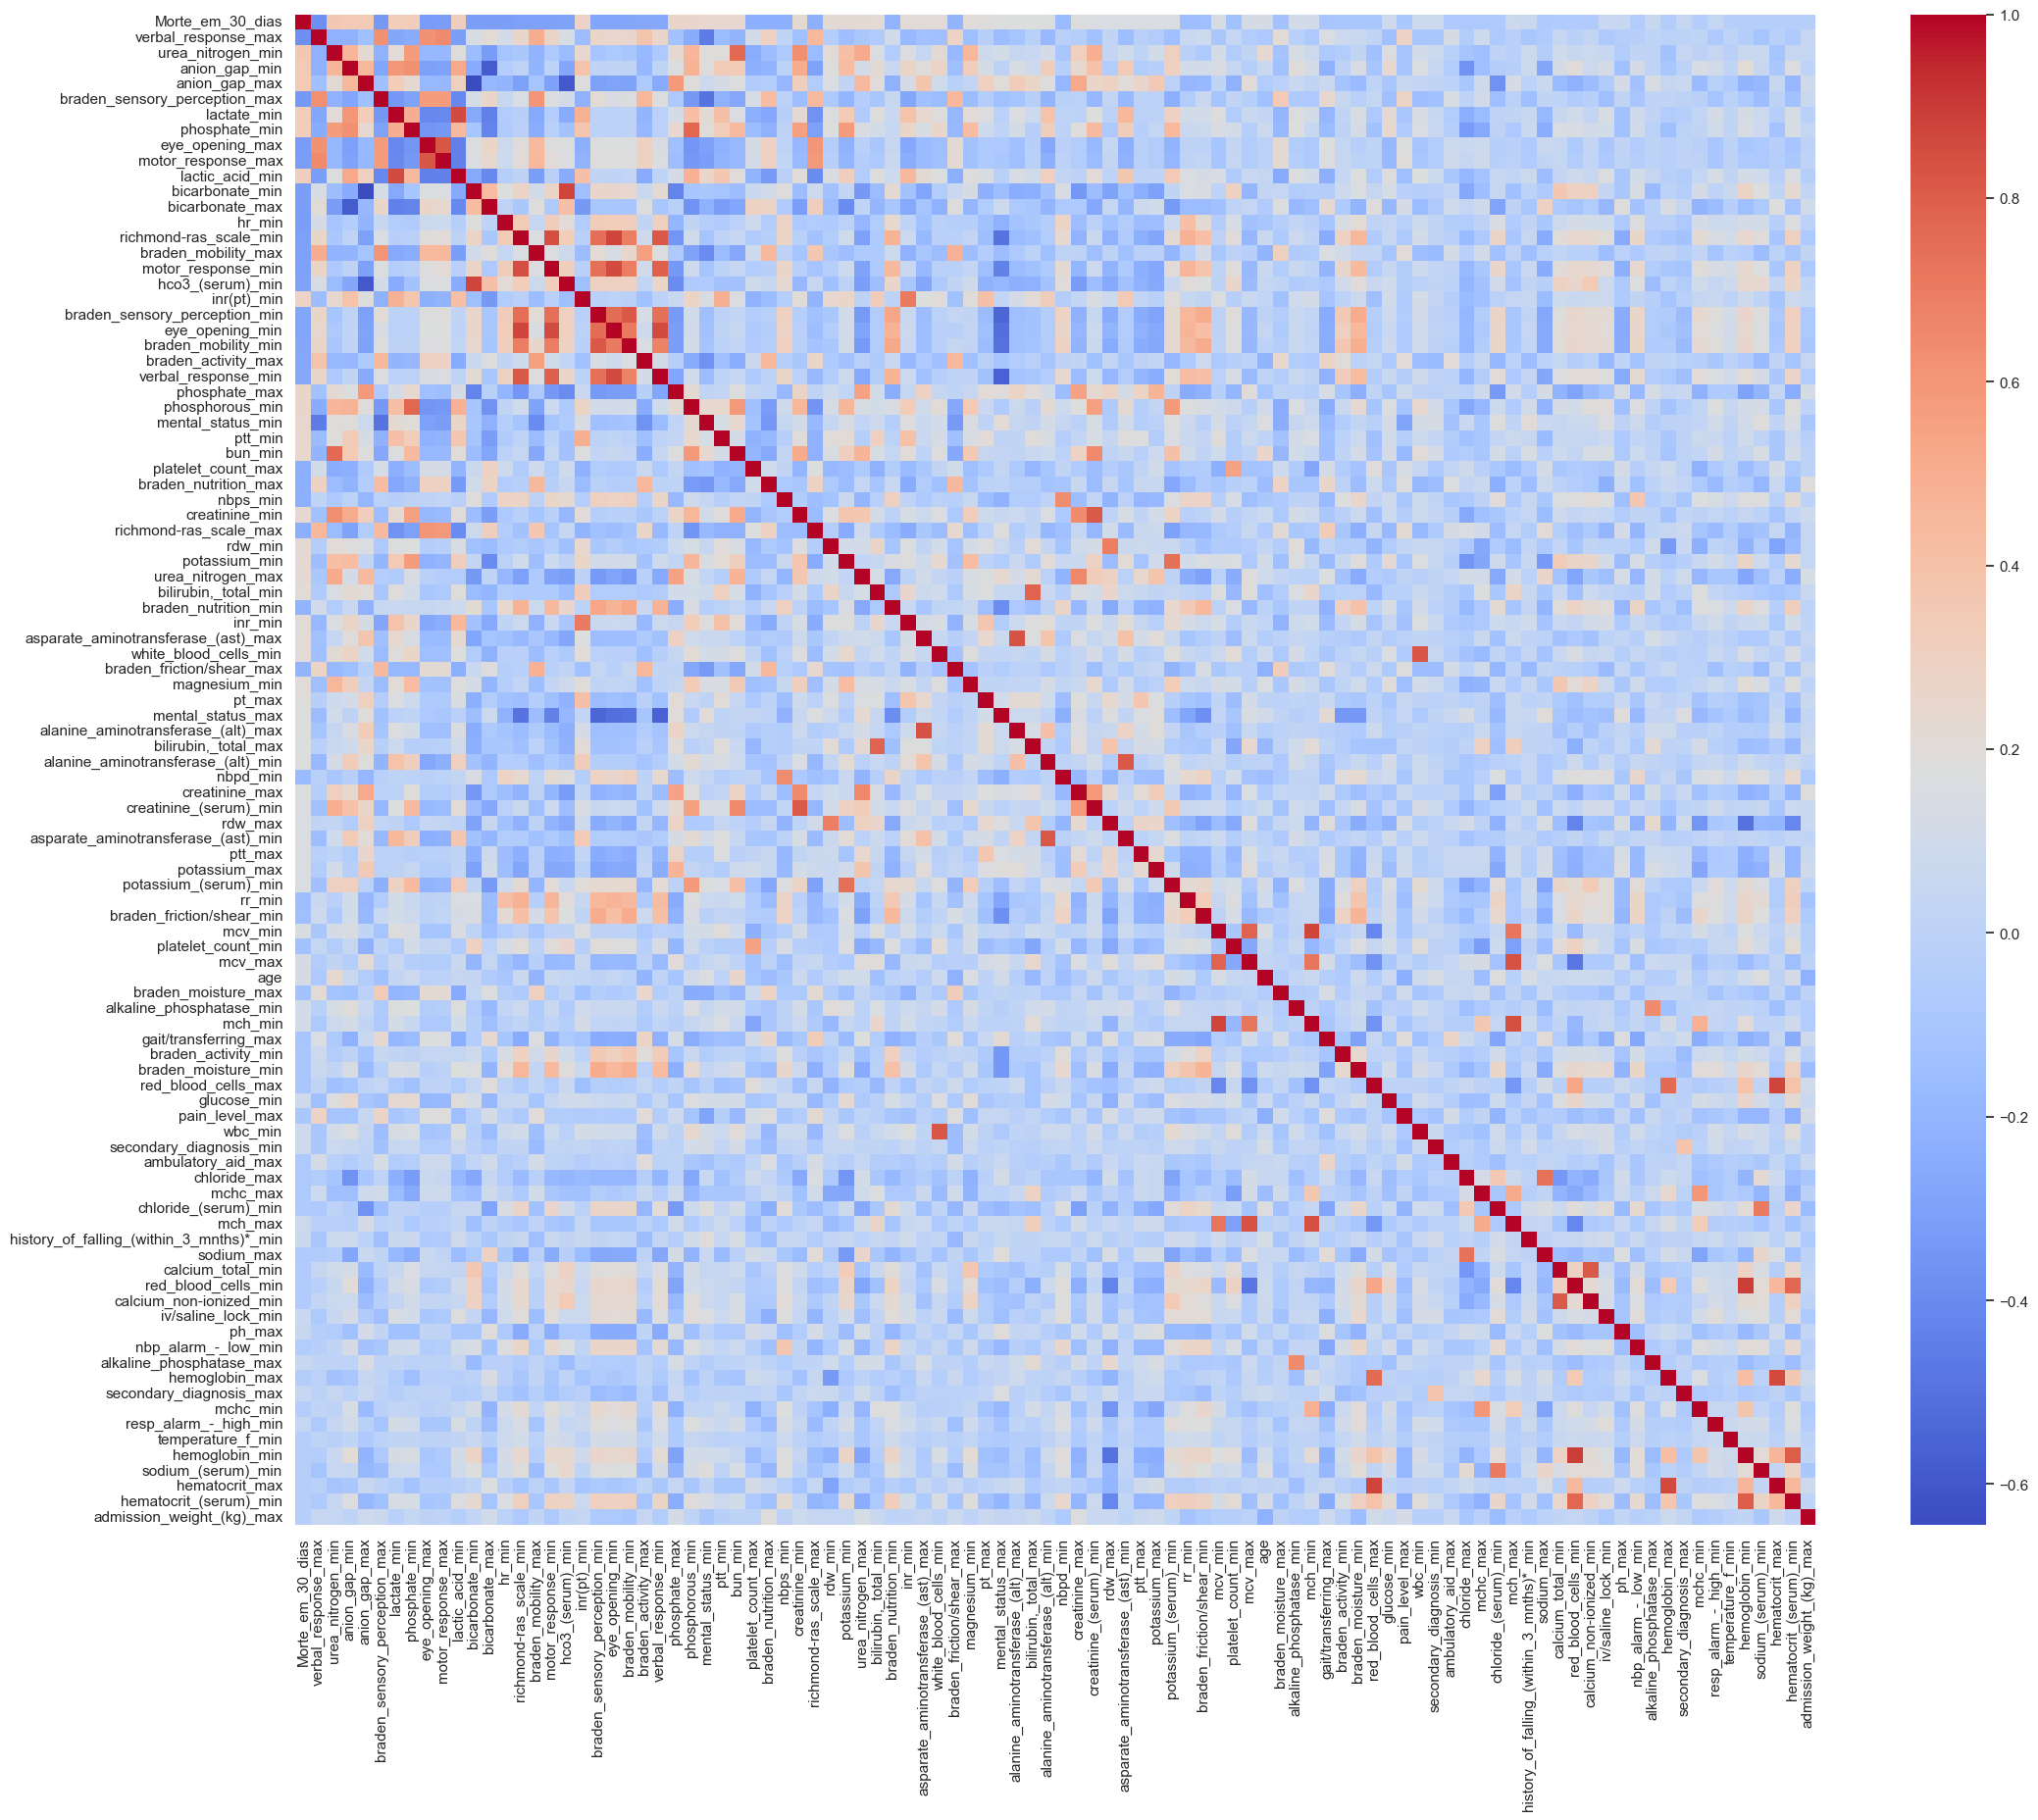

In [39]:
matriz_corr = df_corr.corr()


plt.figure(figsize= (25, 20))
sns.heatmap(matriz_corr, annot= False, cmap= 'coolwarm')

Azuleijos legais, né?

Calma!

Essa é uma imagem apenas ilustrativa, vamos fazer uma análise mais profunda da matriz de correlação futuramente, quando dividirmos as features em categorias, em que cada categoria vai ter uma feature representativa.

In [40]:
colunas_manter = ['subject_id', 'admission_type', 'race', 'gender']

top_corr_morte = list(df_corr.columns)

colunas_manter += top_corr_morte

patients_geral_chart = patients_geral_chart[colunas_manter]

patients_geral_chart['Morte_em_30_dias'] = patients_geral_chart.pop('Morte_em_30_dias')
patients_geral_chart

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\2990457944.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients_geral_chart['Morte_em_30_dias'] = patients_geral_chart.pop('Morte_em_30_dias')


,subject_id,admission_type,race,gender,verbal_response_max,urea_nitrogen_min,anion_gap_min,anion_gap_max,braden_sensory_perception_max,lactate_min,...,secondary_diagnosis_max,mchc_min,resp_alarm_-_high_min,temperature_f_min,hemoglobin_min,sodium_(serum)_min,hematocrit_max,hematocrit_(serum)_min,admission_weight_(kg)_max,Morte_em_30_dias
1,10001843,URGENT,WHITE,M,5.0,27.0,11.0,16.0,3.0,1.7,...,NaN,28.8,35.0,97.500000,9.1,137.0,32.4,31.600000,76.800003,Óbito
2,10002013,EW EMER.,WHITE,F,5.0,12.0,13.0,18.0,4.0,1.2,...,15.0,32.2,35.0,97.199997,9.2,136.0,35.1,28.600000,96.000000,Sobrevivente
3,10002428,EW EMER.,WHITE,F,5.0,13.0,6.0,21.0,4.0,1.2,...,15.0,30.7,30.0,97.000000,7.4,128.0,36.9,23.100000,55.000000,Sobrevivente
4,10003019,EW EMER.,WHITE,M,5.0,15.0,9.0,14.0,4.0,NaN,...,0.0,32.2,30.0,97.599998,7.8,135.0,28.5,24.000000,68.000000,Sobrevivente
5,10003400,URGENT,BLACK/AFRICAN AMERICAN,F,5.0,27.0,8.0,23.0,4.0,0.8,...,15.0,31.7,30.0,95.199997,5.2,128.0,27.2,19.900000,99.599998,Óbito
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14230,19992202,URGENT,WHITE,F,5.0,21.0,12.0,16.0,4.0,1.2,...,15.0,32.5,35.0,99.000000,11.3,138.0,37.9,35.500000,75.000000,Sobrevivente
14231,19992507,OBSERVATION ADMIT,WHITE,F,1.0,14.0,10.0,18.0,2.0,1.3,...,15.0,31.3,35.0,97.500000,14.4,140.0,49.1,46.599998,132.000000,Óbito
14232,19994020,OBSERVATION ADMIT,WHITE,M,5.0,32.0,12.0,34.0,4.0,1.1,...,15.0,30.7,35.0,96.400002,6.3,143.0,34.7,29.400000,86.500000,Sobrevivente
14234,19997367,URGENT,WHITE,F,5.0,12.0,9.0,24.0,4.0,1.2,...,15.0,28.7,30.0,97.000000,6.8,103.0,40.9,24.700001,59.000000,Sobrevivente


Aferindo quais são as top variáveis segundo a correlação

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\1340300528.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_corr_top.head(15), x = 'Correlação', y = 'Variavel', palette= 'viridis')


Text(0.5, 1.0, 'Importância das Features - Correlação')

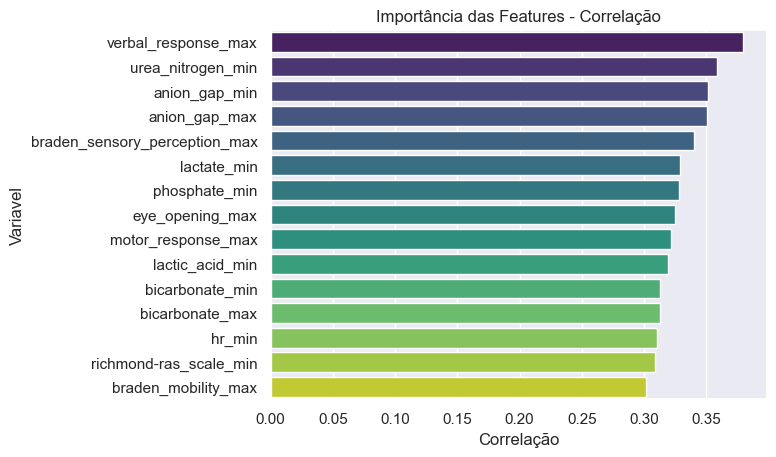

In [41]:
df_corr_top = matriz_corr['Morte_em_30_dias'].abs().sort_values(ascending=False).reset_index()
df_corr_top.columns = ['Variavel', 'Correlação']
df_corr_top = df_corr_top[df_corr_top['Variavel'] != 'Morte_em_30_dias']
sns.barplot(data = df_corr_top.head(15), x = 'Correlação', y = 'Variavel', palette= 'viridis')
plt.title("Importância das Features - Correlação")

### Tratando dados nulos

Removendo colunas com muitos dados nulos

In [42]:
# vendo a qtde de dados nulos por coluna
df_nulos = patients_geral_chart.isnull().sum().reset_index()
df_nulos.columns = ['coluna', 'count']
df_nulos.sort_values(by = 'count', ascending= False)

,coluna,count
74,pain_level_max,1485
51,alanine_aminotransferase_(alt)_min,1329
49,alanine_aminotransferase_(alt)_max,1329
67,alkaline_phosphatase_min,1307
90,alkaline_phosphatase_max,1307
...,...,...
2,race,0
1,admission_type,0
0,subject_id,0
65,age,0


In [43]:
df_nulos = patients_geral_chart.isnull().sum().reset_index()
df_nulos.columns = ['coluna', 'count']
df_nulos.describe()

,count
count,102.000000
mean,239.441176
std,414.604227
min,0.000000
25%,26.000000
50%,39.000000
75%,118.000000
max,1485.000000


Agora temos uma quantidade aceitável de dados nulos por coluna, vamos ver a distribuição de dados nulos pelo número de pacientes

In [44]:
qtde_nulos_per_patients = patients_geral_chart.set_index("subject_id").isnull().mean(axis=1) * 100
qtde_nulos_per_patients = qtde_nulos_per_patients.reset_index()
qtde_nulos_per_patients.columns = ['subject_id', 'count']
qtde_nulos_per_patients.describe()

,subject_id,count
count,1.163800e+04,11638.000000
mean,1.501721e+07,2.077779
std,2.888493e+06,4.728231
min,1.000184e+07,0.000000
25%,1.250868e+07,0.000000
50%,1.503384e+07,0.000000
75%,1.754768e+07,1.980198
max,1.999789e+07,87.128713


Ok, a maioria dos pacientes tem em média uma quantidade pequena de dados nulos, acho que vale verificar quantos tem todos os dados preenchidos

In [45]:
num_preenchidos = (qtde_nulos_per_patients['count'] == 0).sum()
total_pacientes = len(qtde_nulos_per_patients['count'])
print(f"Pacientes com 0% de dados nulos: {num_preenchidos} ({(num_preenchidos / total_pacientes) * 100:.2f}%)")


Pacientes com 0% de dados nulos: 6965 (59.85%)


Para a **minha realidade**, acho que vale deixar somente pacientes com todos os dados preenchidos porque já temos uma qtde razoável de amostras e que não temos tanto conhecimento sobre as variáveis. Entretanto, o caminho "correto" deveria fazer:

- Um equilíbrio entre qtde de dados nulos por paciente e o número de pacientes(qual porcentagem máx que permitimos de dados nulos por paciente?)
- Preencher esses dados nulos de alguma forma(com mediana, média, moda, valores nulos, etc) -> Aqui é interessante ter certo conhecimento sobre as variáveis para saber a melhor forma de preencher. Além disso, uma saída bem legal seria também preencher os valores nulos usando KNN, preenchendo os valores ausentes com base nos pacientes mais similares.

In [46]:
# dropando pacientes com valores nulos
patients_geral_chart.dropna(inplace= True)
patients_geral_chart.reset_index(drop= True, inplace= True)
patients_geral_chart

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\2924430867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients_geral_chart.dropna(inplace= True)


,subject_id,admission_type,race,gender,verbal_response_max,urea_nitrogen_min,anion_gap_min,anion_gap_max,braden_sensory_perception_max,lactate_min,...,secondary_diagnosis_max,mchc_min,resp_alarm_-_high_min,temperature_f_min,hemoglobin_min,sodium_(serum)_min,hematocrit_max,hematocrit_(serum)_min,admission_weight_(kg)_max,Morte_em_30_dias
0,10002428,EW EMER.,WHITE,F,5.0,13.0,6.0,21.0,4.0,1.2,...,15.0,30.7,30.0,97.000000,7.4,128.0,36.9,23.100000,55.000000,Sobrevivente
1,10003400,URGENT,BLACK/AFRICAN AMERICAN,F,5.0,27.0,8.0,23.0,4.0,0.8,...,15.0,31.7,30.0,95.199997,5.2,128.0,27.2,19.900000,99.599998,Óbito
2,10003637,EW EMER.,PORTUGUESE,M,5.0,42.0,15.0,22.0,4.0,0.8,...,15.0,30.7,35.0,94.900002,10.1,132.0,42.8,31.799999,88.000000,Óbito
3,10004235,URGENT,BLACK/CAPE VERDEAN,M,5.0,32.0,13.0,28.0,4.0,1.4,...,15.0,31.9,35.0,98.000000,8.5,129.0,38.7,29.400000,127.000000,Sobrevivente
4,10004401,EW EMER.,WHITE,M,5.0,48.0,11.0,30.0,4.0,1.0,...,15.0,30.5,20.0,69.000000,6.2,125.0,32.8,19.799999,90.699997,Óbito
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6960,19985545,OBSERVATION ADMIT,WHITE - OTHER EUROPEAN,M,5.0,8.0,5.0,13.0,4.0,1.0,...,15.0,30.7,30.0,97.199997,6.0,126.0,26.2,20.000000,75.000000,Sobrevivente
6961,19986880,SURGICAL SAME DAY ADMISSION,UNKNOWN,F,5.0,20.0,14.0,32.0,4.0,1.7,...,15.0,33.5,30.0,37.799999,7.9,126.0,38.0,24.799999,58.799999,Óbito
6962,19988077,URGENT,WHITE,M,5.0,11.0,9.0,18.0,4.0,1.4,...,15.0,32.0,30.0,97.199997,7.7,131.0,33.1,22.500000,71.000000,Sobrevivente
6963,19991446,EW EMER.,WHITE,F,5.0,15.0,6.0,18.0,4.0,0.6,...,15.0,31.4,35.0,97.000000,6.4,139.0,30.5,19.100000,58.000000,Sobrevivente


## Análise exploratória

Aqui o correto seria separar os dados de treino e teste e fazer a Análise Exploratória somente para os dados de teste para evitar o chamado **data leakage**. Entretanto, por simplicidade, decidi tratar todos juntos.

Um exemplo de como isso pode causar problemas é na remoção de outliers(que é um dos nossos próximos passos hahaha): 

Suponha que eu defina limites de outliers com base no percentil 1 e 99 considerando todos os dados. Isso pode levar à remoção indevida de pontos que deveriam estar no treino ou à retenção de valores atípicos no teste, distorcendo a distribuição real dos dados e comprometendo a generalização do modelo.

Antes de prosseguirmos, como temos muitas variáveis, é relativamente inviável analisar uma por uma, por isso vamos utilizar a mesma abordagem desse [outro artigo](https://www.computer.org/csdl/proceedings-article/medai/2024/776100a546/22XNUx5tUhW), que divide todos os sinais vitais e exames laboratoriais em 10 grupos, cada grupo tem uma feature representativa:

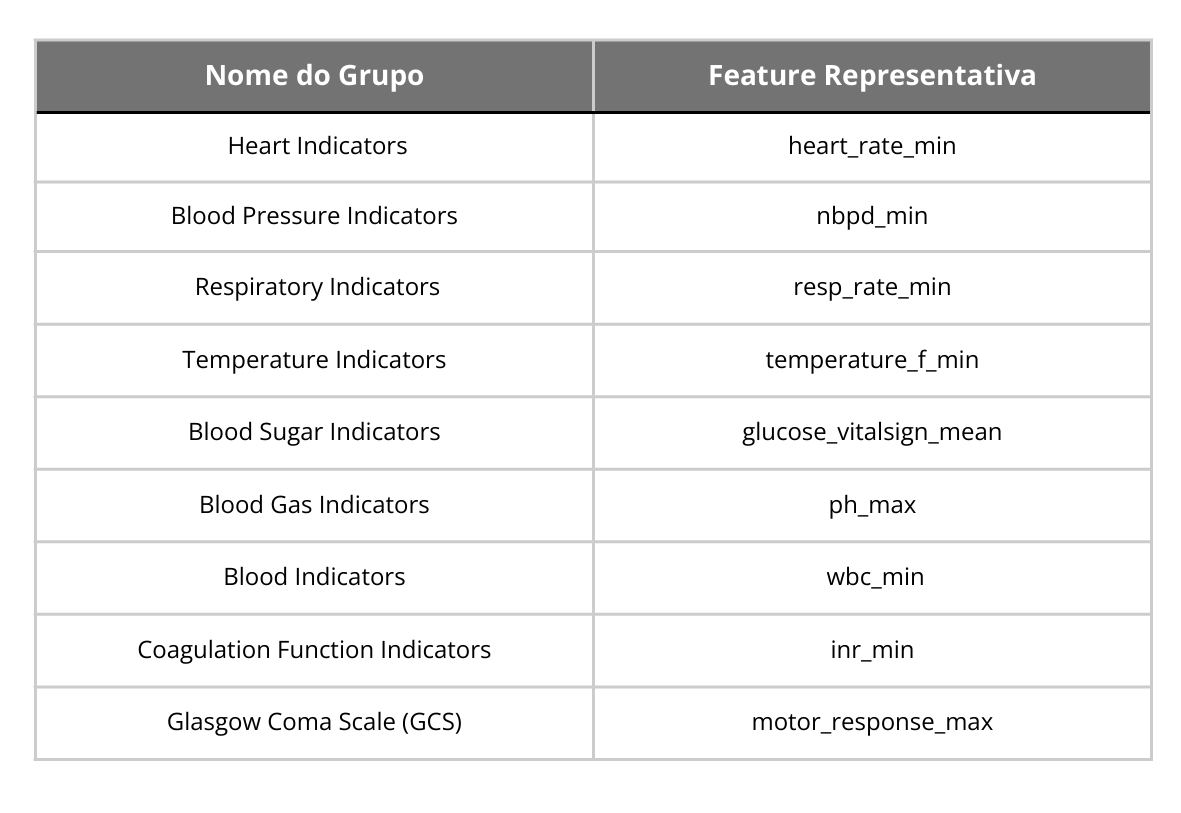


Essas features representativas foram escolhidas também de acordo com o artigo, que tem embasamento médico.

### Taxa de mortalidade geral

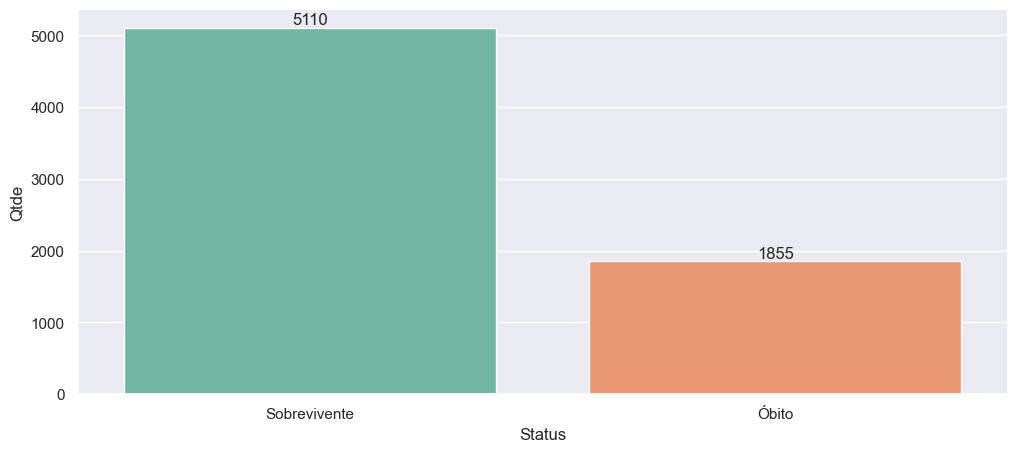

In [47]:
df_plot = patients_geral_chart['Morte_em_30_dias'].value_counts().reset_index()
df_plot.columns = ['Morte_em_30_dias', 'Qtde']
df_plot['Morte_em_30_dias'] = df_plot['Morte_em_30_dias'].astype(str)

sns.set_theme()
plt.figure(figsize=(12, 5))
ax = sns.barplot(data = df_plot,
            x = 'Morte_em_30_dias',
            y = 'Qtde',
            hue = 'Morte_em_30_dias',
            legend= False, 
            palette= "Set2")

ax.bar_label(ax.containers[0], fmt='%d', fontsize=12)
ax.bar_label(ax.containers[1], fmt='%d', fontsize=12)
plt.ylabel('Qtde')
plt.xlabel('Status')
plt.show()

Evidentemente, temos um desbalanceamento das classes. Manteremos assim, vamos contornar isso através de parâmetros nos modelos que utilizaremos.

Além disso, perceba que a taxa de mortalidade é de 26.6%, não tão distante da mortalidade do Brasil, como comentei no começo.

### Distribuição de variáveis numéricas representativas(Exames e Sinais Vitais) e Idade

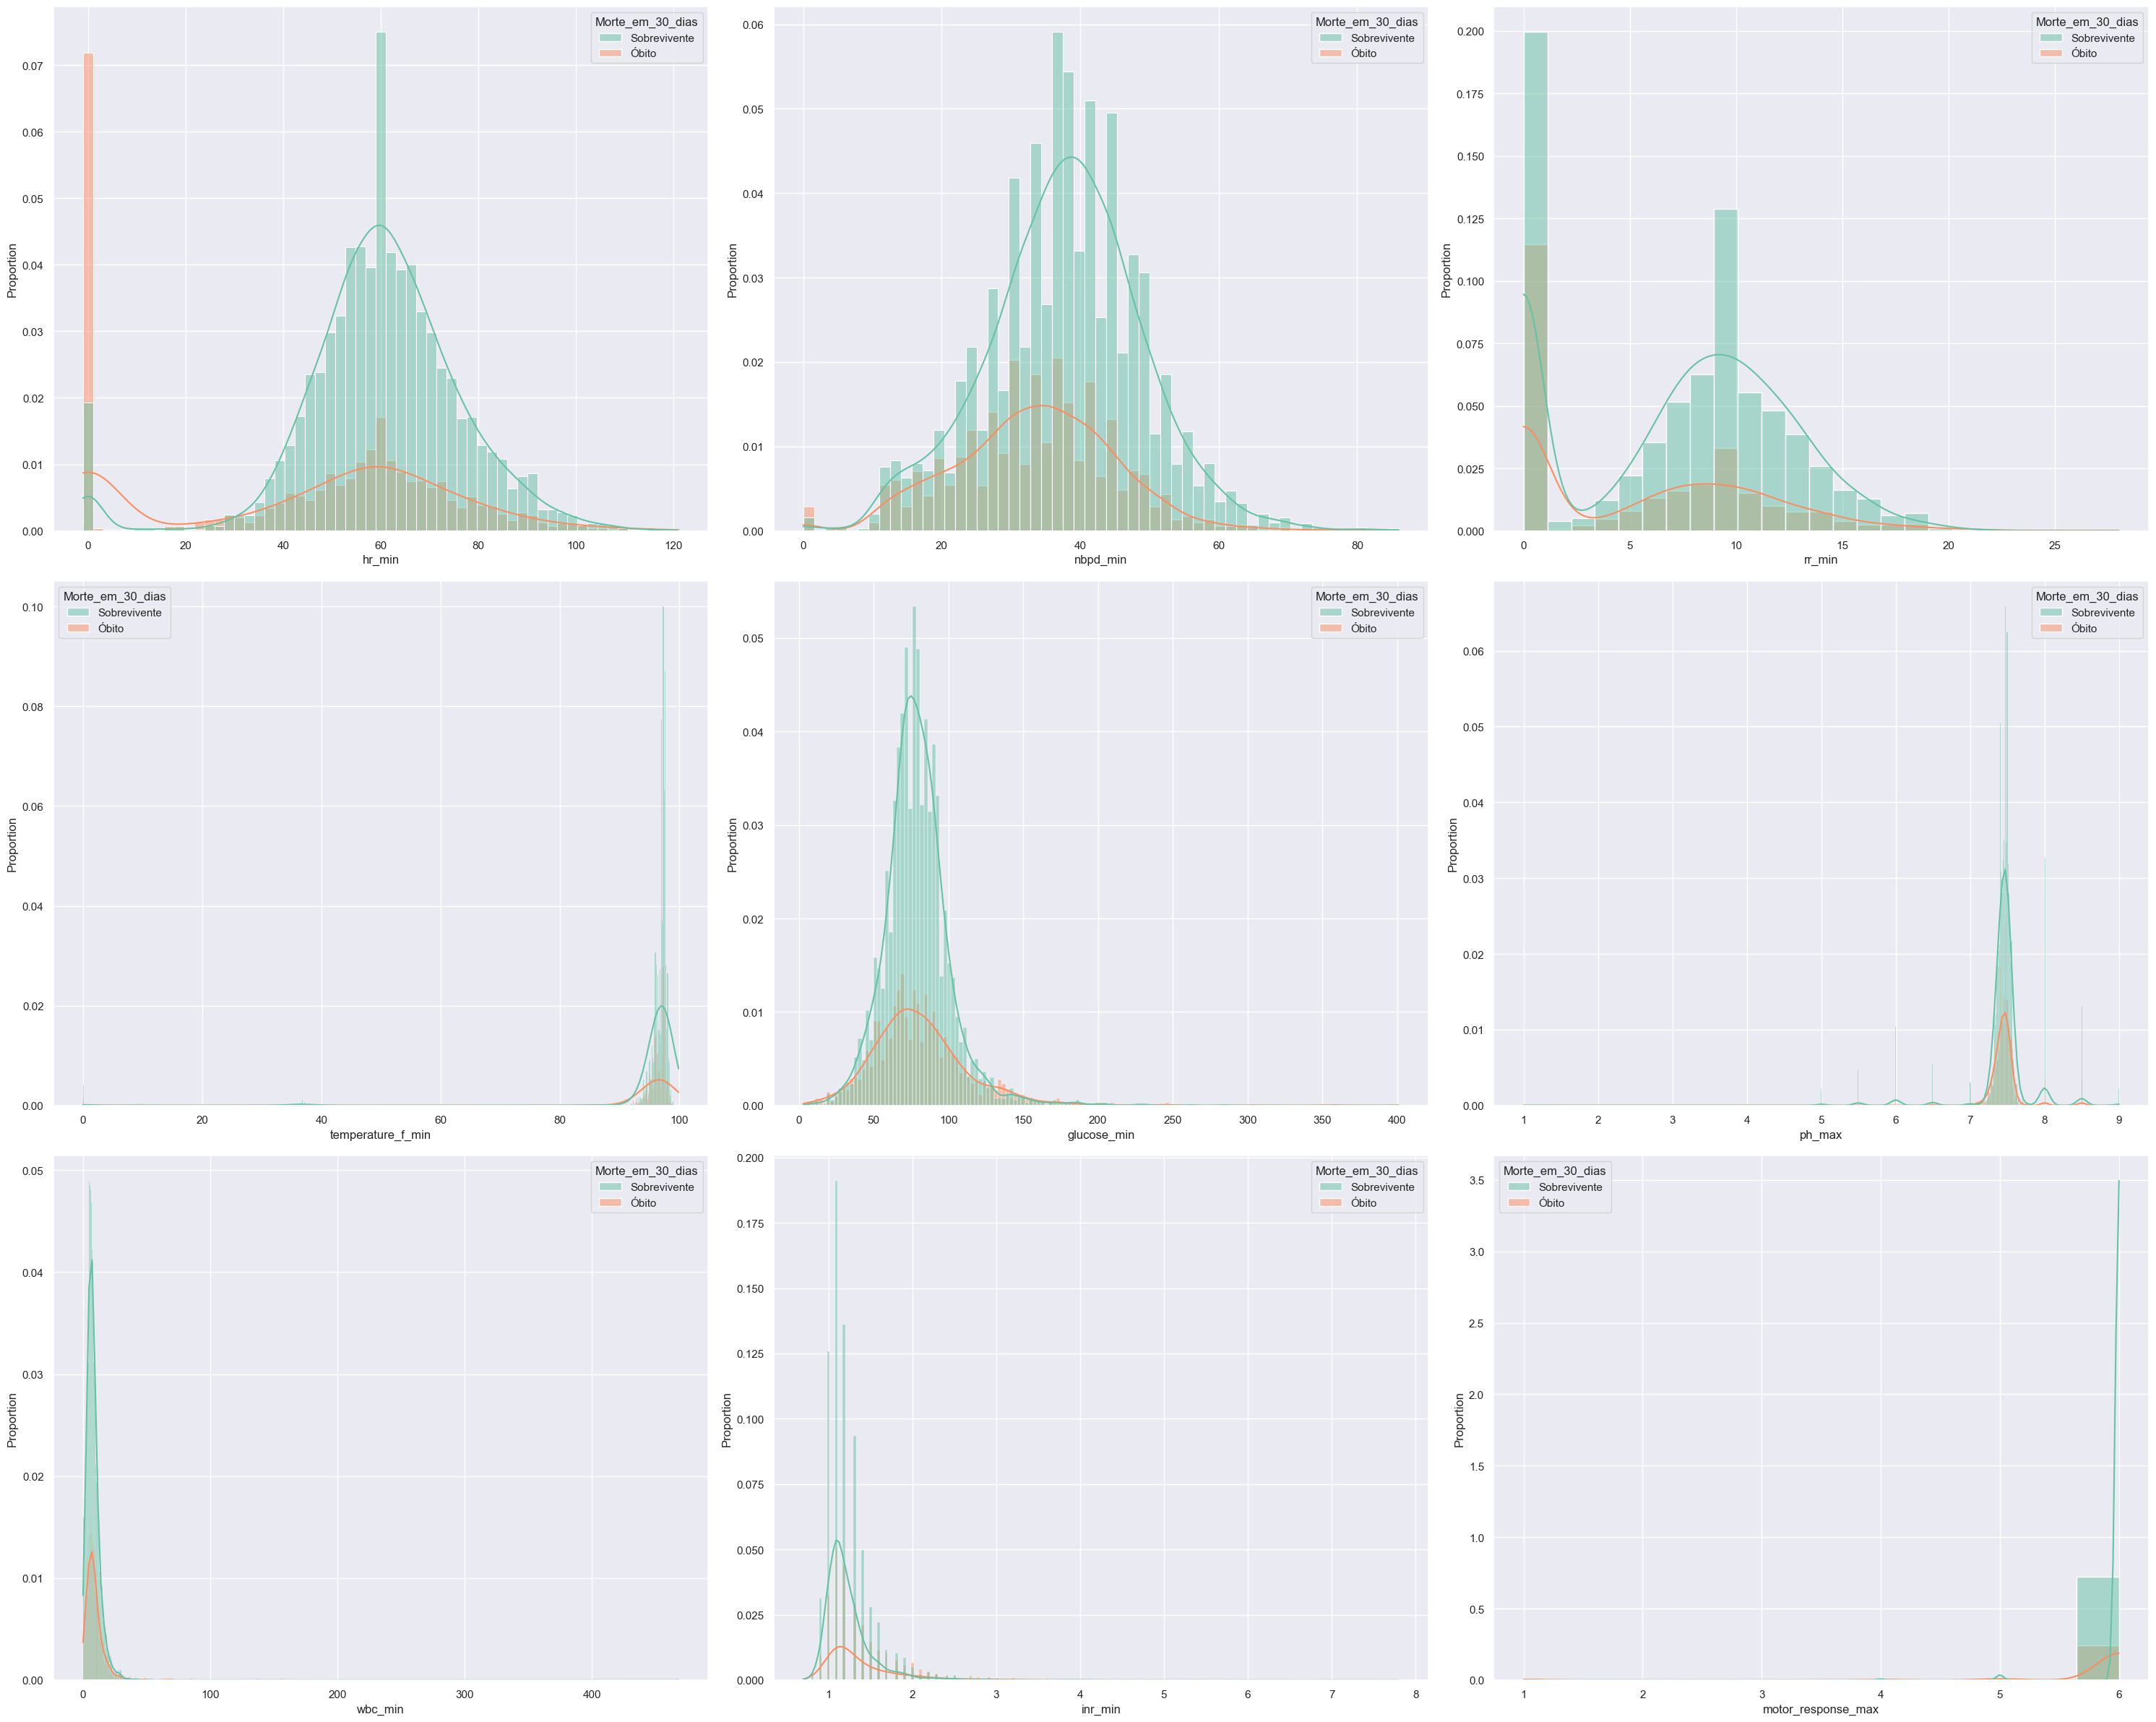

In [48]:
variaveis_represent = ['hr_min', 'nbpd_min', 'rr_min', 'temperature_f_min', 
                        'glucose_min', 'ph_max', 'wbc_min', 'inr_min', 'motor_response_max']

# Configuração da figura
fig, axes = plt.subplots(3, 3, figsize=(30, 24))
axes = axes.flatten()

for i, var in enumerate(variaveis_represent):
    sns.histplot(data=patients_geral_chart, x=var, hue="Morte_em_30_dias", palette= "Set2", kde=True, stat="proportion", ax=axes[i])
    ax.set_xlabel(var, fontsize = 18)
    ax.set_ylabel("Proportion", fontsize = 18)
    ax.tick_params(axis='both', labelsize=16)


plt.tight_layout()
plt.show()

Insights:

- `hr_min`: Heart Rate
    - Pacientes que foram a óbito apresentam um acúmulo significativo de valores próximos de 0 bpm, sugerindo registros de paradas cardíacas antes do óbito.
    - O pico incomum em 60 bpm, acredito ser devido a arredondamento ou registros padrão em medições.

- `nbpd_min`: Pressão Arterial Diastólica
    - Pacientes que foram a óbito tendem a apresentar valores menores, com uma distribuição mais deslocada para a esquerda em comparação aos sobreviventes.

- Comentários gerais:
    - `rr_min` e `hr_min` apresentam **valores extremamente baixos**, com picos em `0`, que podem indicar registros de **parada respiratória ou cardíaca** ou dados ausentes preenchidos incorretamente.
    - `wbc_min` e `glucose_min` possuem distribuições assimétricas com **caudas longas**, o que pode indicar casos extremos que exigem análise mais aprofundada.
    - Em quase todas as variáveis, pacientes que foram a óbito apresentam **distribuições mais deslocadas para valores extremos** (ex: `nbpd_min` mais baixo, `ph_max` abaixo do esperado).
   - O `motor_response_max` apresenta forte assimetria, com a maioria dos sobreviventes próximos ao limite máximo da escala.
   - Parâmetros fisiológicos mais baixos, como **pressão arterial (`nbpd_min`), frequência cardíaca (`hr_min`) e pH (`ph_max`)**, parecem estar associados a maior mortalidade -> Vamos confirmar isso mais pra frente

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\4059800775.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = patients_geral_chart.groupby([pd.cut(patients_geral_chart['age'], bins=bins), 'Morte_em_30_dias']).size().unstack(fill_value=0)


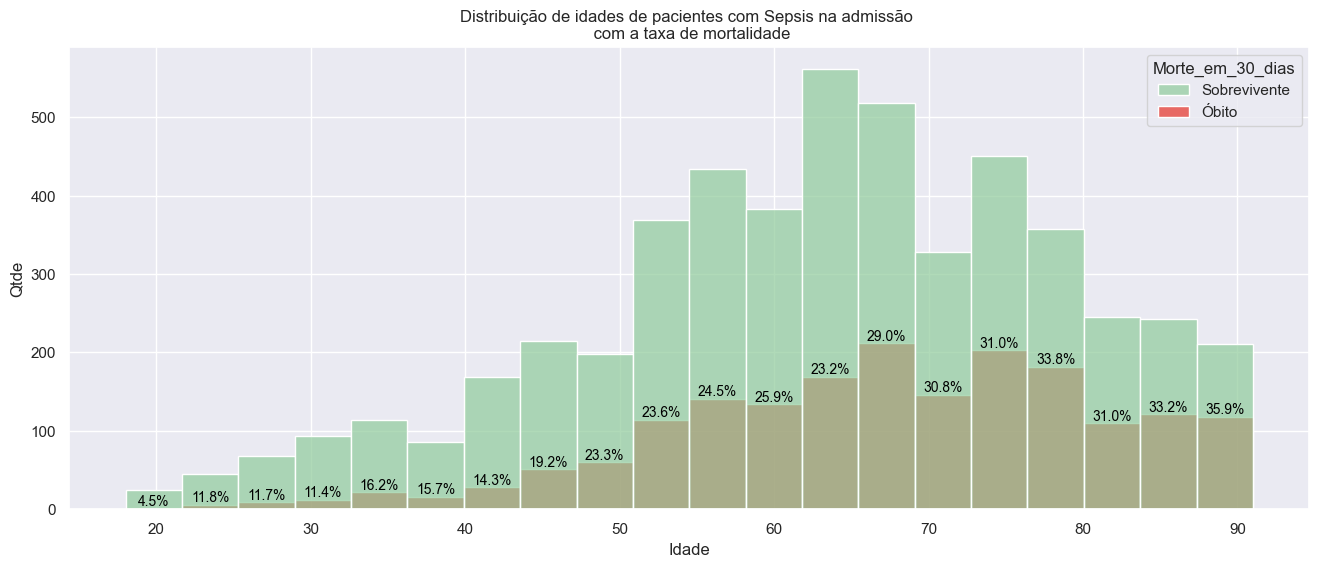

In [ ]:
import numpy as np
# bins são as faixa etárias
bins = np.histogram_bin_edges(patients_geral_chart['age'], bins=20)

# Agrupando os dados por faixa de idade e contando os casos de óbito e sobrevivente
df_plot = patients_geral_chart.groupby([pd.cut(patients_geral_chart['age'], bins=bins), 'Morte_em_30_dias']).size().unstack(fill_value=0)

# Caso os valores sejam strings, podemos mapeá-los
if 'Óbito' in patients_geral_chart.columns and 'Sobrevivente' in patients_geral_chart.columns:
    df_plot['taxa_mortalidade'] = df_plot['Óbito'] / (df_plot['Óbito'] + df_plot['Sobrevivente'])
else:

    morte_col = patients_geral_chart['Morte_em_30_dias'].max() 
    sobrevivente_col = patients_geral_chart['Morte_em_30_dias'].min()
    
    df_plot['taxa_mortalidade'] = df_plot[morte_col] / (df_plot[morte_col] + df_plot[sobrevivente_col])

plt.figure(figsize=(16, 6))

ax = sns.histplot(data=patients_geral_chart,
                  x='age', 
                  hue='Morte_em_30_dias', 
                  palette={"Óbito": "#E63228", "Sobrevivente": "#8FCB9B"}, alpha=0.7, bins=bins)


for i, (bar, taxa) in enumerate(zip(ax.patches, df_plot['taxa_mortalidade'])):
    if not np.isnan(taxa):  # Evitar erro em divisões por zero
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        ax.text(x, y, f'{taxa:.1%}', ha='center', va='bottom', fontsize=10, color='black')

# Ajustando rótulos do gráfico
plt.title('Distribuição de idades de pacientes com Sepsis na admissão \n com a taxa de mortalidade')
plt.xlabel('Idade')
plt.ylabel('Qtde')

plt.show()

- A taxa de mortalidade em geral aumenta progressivamente com a idade, conforme o esperado

### Outliers

Como não temos tanto conhecimento médico sobre as variáveis, não conseguimos identificar facilmente quando um valor é um erro de medição ou apenas um extremo fisiológico legítimo. Para contornar isso, vamos identificar outliers de forma mais "generosa", considerando valores que estão além de **5 desvios-padrão** da média.

Isso significa que, em vez de remover qualquer valor atípico, estamos focando apenas em **valores extremamente fora do padrão esperado**, minimizando o risco de excluir dados válidos. Primeiramente, vamos avaliar a porcentagem de outliers por variável segundo esse critério:

In [60]:
colunas_manter = ['subject_id', 'admission_type', 'race', 'gender', 'age', 'Morte_em_30_dias']
num_col = [col for col in patients_geral_chart.columns if col not in colunas_manter]

outlier_counts = {}
outliers_ext = {}

# 1️Identificar os outliers extremos
for col in num_col:

    Q1 = patients_geral_chart[col].quantile(0.25)
    Q3 = patients_geral_chart[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lim_inf = Q1 - 5 * IQR
    lim_sup = Q3 + 5 * IQR

    # Identificar
    outliers = (patients_geral_chart[col] < lim_inf) | (patients_geral_chart[col] > lim_sup)
    outlier_counts[col] = outliers.sum()
    
    # Armazena outliers para a possível substituição futura
    outliers_ext[col] = outliers


outlier_counts_df = pd.DataFrame(list(outlier_counts.items()), columns=['Coluna', 'Número de Extremos'])
outlier_counts_df["Porcentagem de Outliers (%)"] = ((outlier_counts_df['Número de Extremos'] / len(patients_geral_chart)) * 100).round(2)
outlier_counts_df.sort_values(by='Número de Extremos', ascending=False, inplace= True)
outlier_counts_df

,Coluna,Número de Extremos,Porcentagem de Outliers (%)
29,braden_nutrition_max,2003,28.76
71,secondary_diagnosis_min,1327,19.05
4,braden_sensory_perception_max,1307,18.77
72,ambulatory_aid_max,1274,18.29
77,history_of_falling_(within_3_mnths)*_min,1148,16.48
...,...,...,...
82,iv/saline_lock_min,0,0.00
91,hemoglobin_min,0,0.00
88,mchc_min,0,0.00
93,hematocrit_max,0,0.00


Vamos olhar de perto as variáveis que tem mais de 10% de Outliers, através dos boxplots:

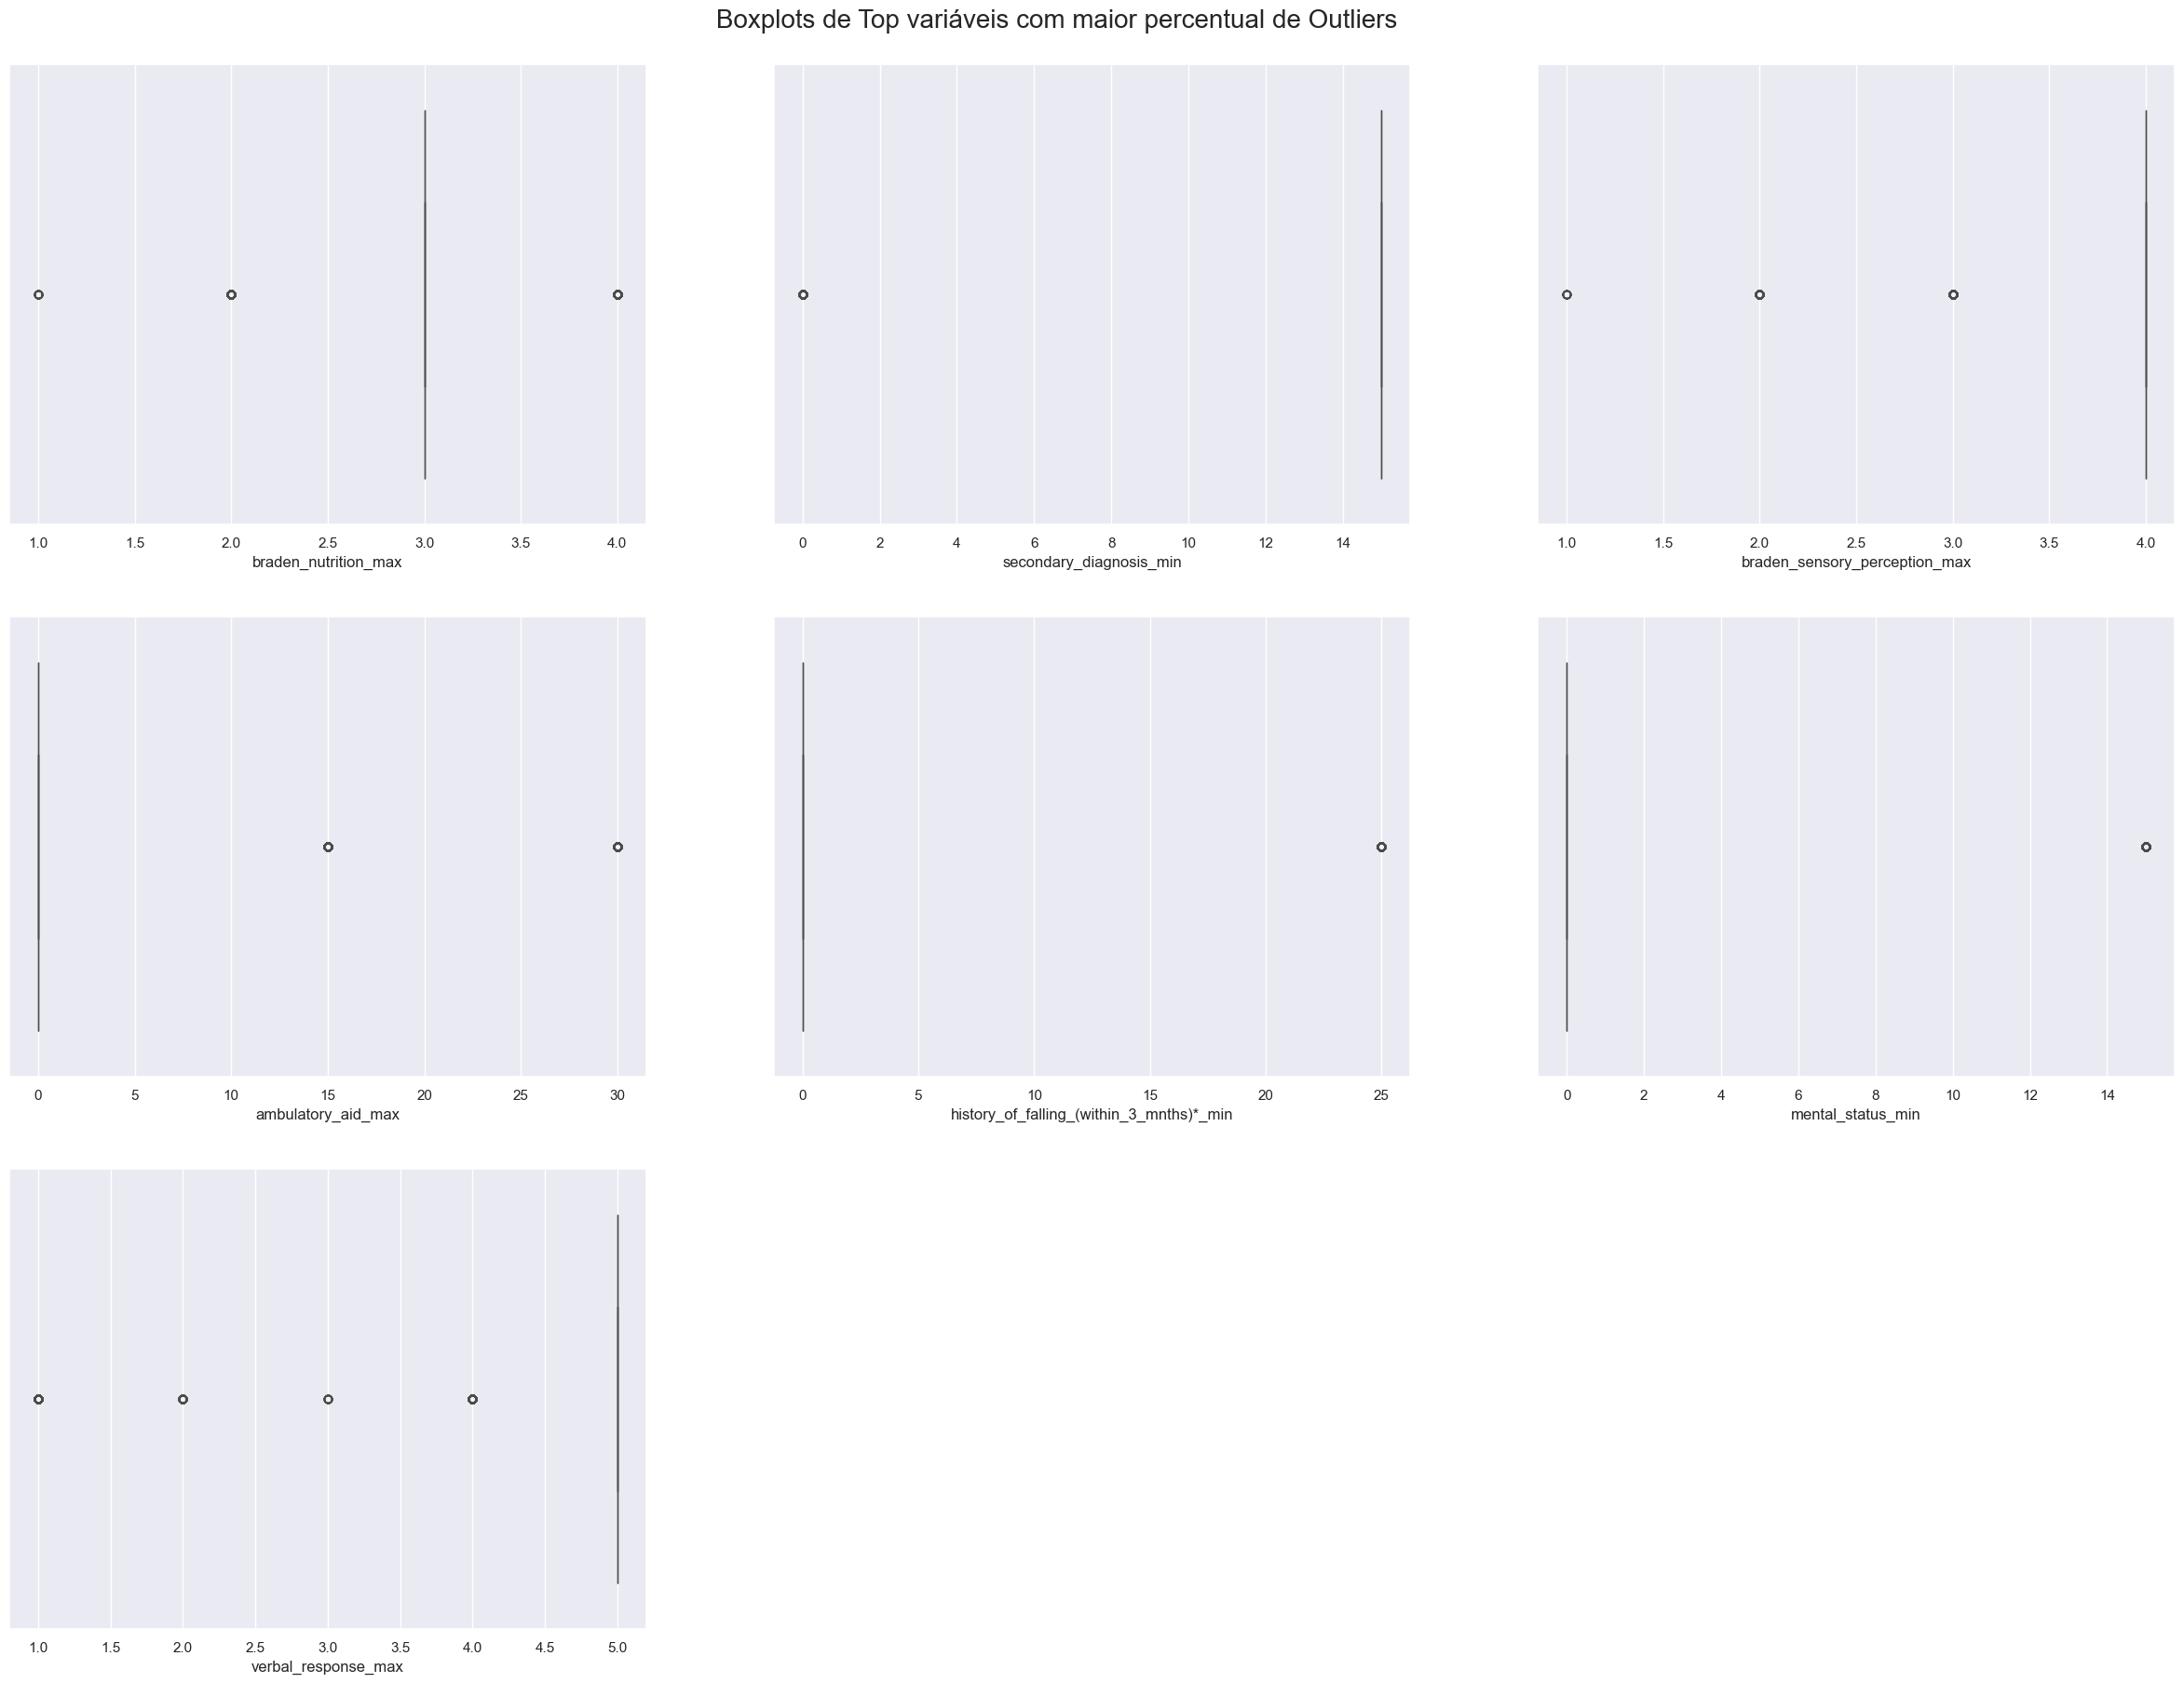

In [61]:
top_out_columns = list(outlier_counts_df[outlier_counts_df['Porcentagem de Outliers (%)'] > 10]['Coluna'])

n_cols = 3
n_rows = int(np.ceil(len(top_out_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 20))
plt.suptitle('Boxplots de Top variáveis com maior percentual de Outliers', fontsize = 20)

axes = axes.flatten()

for i, col in enumerate(top_out_columns):
    sns.boxplot(data=patients_geral_chart, x=col, ax=axes[i])
    ax.set_xlabel(col, fontsize = 18)
    ax.tick_params(axis='both', labelsize=16)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.subplots_adjust(top=0.95)
plt.show()


- Observe que algumas variáveis possuem poucos valores distintos, indicando que na verdade são índices, como vemos claramente em `braden_nutrion_max`, `branden_sensory_perception_max`, `verbal_response_max`. Essas devem ser mantidas como estão, sem substituição de outliers.

In [59]:
# identificando variáveis que na verdade são indices
indices_col = [col for col in num_col if patients_geral_chart[col].nunique() <= 10]
print(indices_col)

['verbal_response_max', 'braden_sensory_perception_max', 'eye_opening_max', 'motor_response_max', 'richmond-ras_scale_min', 'braden_mobility_max', 'motor_response_min', 'braden_sensory_perception_min', 'eye_opening_min', 'braden_mobility_min', 'braden_activity_max', 'verbal_response_min', 'mental_status_min', 'braden_nutrition_max', 'richmond-ras_scale_max', 'braden_nutrition_min', 'braden_friction/shear_max', 'mental_status_max', 'braden_friction/shear_min', 'braden_moisture_max', 'gait/transferring_max', 'braden_activity_min', 'braden_moisture_min', 'secondary_diagnosis_min', 'ambulatory_aid_max', 'history_of_falling_(within_3_mnths)*_min', 'iv/saline_lock_min', 'secondary_diagnosis_max']


(realmente tem cara de índices, o certo seria investigarmos um pouquinho)

- Observe que as outras variáveis(`ambulatory_aid_max`, `history_of_falling_(within_3_mnths)*_min`, `mental_status_min`, `secondary_diagnosis_min`) nos boxplots tem a maioria dos valores centrados em zero, observando os valores únicos, percebemos algo similar, desse modo, elas cairiam na mesma situação anterior

In [62]:
for col in ['ambulatory_aid_max', 'history_of_falling_(within_3_mnths)*_min', 'mental_status_min', 'secondary_diagnosis_min']:
    # per_zeros = patients_geral_chart[patients_geral_chart[col] == 0][col].count()/len(patients_geral_chart)
    # print(f'Porcentagem de zeros em {col}: {per_zeros:.2f}')
    print(patients_geral_chart[col].unique())

[ 0. 15. 30.]
[ 0. 25.]
[ 0. 15.]
[15.  0.]


- Para variáveis contínuas com menos de 10% de outliers, substituir os valores extremos pela moda, pois são provavelmente erros de medição.

In [63]:
for col in num_col:
    if col not in indices_col:
        moda = patients_geral_chart[col].mode().iloc[0] if not patients_geral_chart[col].mode().empty else np.nan
        patients_geral_chart.loc[outliers_ext[col], col] = moda

Vamos verificar a porcentagem de outliers, mas pelo critério padrão de 1.5xIQR

In [155]:
colunas_manter = ['subject_id', 'admission_type', 'race', 'gender', 'age', 'Morte_em_30_dias']
num_col = [col for col in patients_geral_chart.columns if col not in colunas_manter]

outlier_counts = {}
outliers_ext = {}

for col in num_col:
    if col not in indices_col:

        Q1 = patients_geral_chart[col].quantile(0.25)
        Q3 = patients_geral_chart[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR

        # Identificar
        outliers = (patients_geral_chart[col] < lim_inf) | (patients_geral_chart[col] > lim_sup)
        outlier_counts[col] = outliers.sum()

outlier_counts_df = pd.DataFrame(list(outlier_counts.items()), columns=['Coluna', 'Número de Outliers'])
outlier_counts_df["Porcentagem de Outliers (%)"] = ((outlier_counts_df['Número de Outliers'] / len(patients_geral_chart)) * 100).round(2)
outlier_counts_df.sort_values(by='Número de Outliers', ascending=False, inplace= True)
outlier_counts_df.drop(columns = 'Número de Outliers')[outlier_counts_df['Porcentagem de Outliers (%)'] != 0].reset_index(drop = True).head(10)

,Coluna,Porcentagem de Outliers (%)
0,inr_min,13.31
1,asparate_aminotransferase_(ast)_max,11.47
2,alanine_aminotransferase_(alt)_max,10.98
3,"bilirubin,_total_max",10.84
4,hr_min,10.54
5,"bilirubin,_total_min",8.76
6,inr(pt)_min,8.44
7,creatinine_min,8.04
8,asparate_aminotransferase_(ast)_min,7.98
9,alkaline_phosphatase_max,7.81


A porcentagem de outliers são baixas em cada feature. Além disso, acredito que erros de medição já foram retirados, não vamos remover o resto.

### Distribuição de Variáveis Categóricas
Como varáveis categóricas, temos `admission_type`, `race` e `gender`;

- `race`: Tipo de raça(aqui não tem uma padronização definida, portanto vamos agrupar futuramente)
- `admission_type`: Diz o tipo de admissão, ex: Urgência, proveniente de uma Cirurgia, Observação, etc. Entendemos essa variável também como um indicador da gravidade do paciente, que pode influenciar no óbito.
- `gender`: Female ou Male

Como veremos, para `raça` e `admission_type`, como algumas categorias têm pouquíssimos exemplos, enquanto outras dominam o conjunto de dados. Isso pode fazer com que o modelo aprenda padrões enviesados.

Famos precisar agrupar em categorias mais gerais:

Avaliando a Raça primeiro

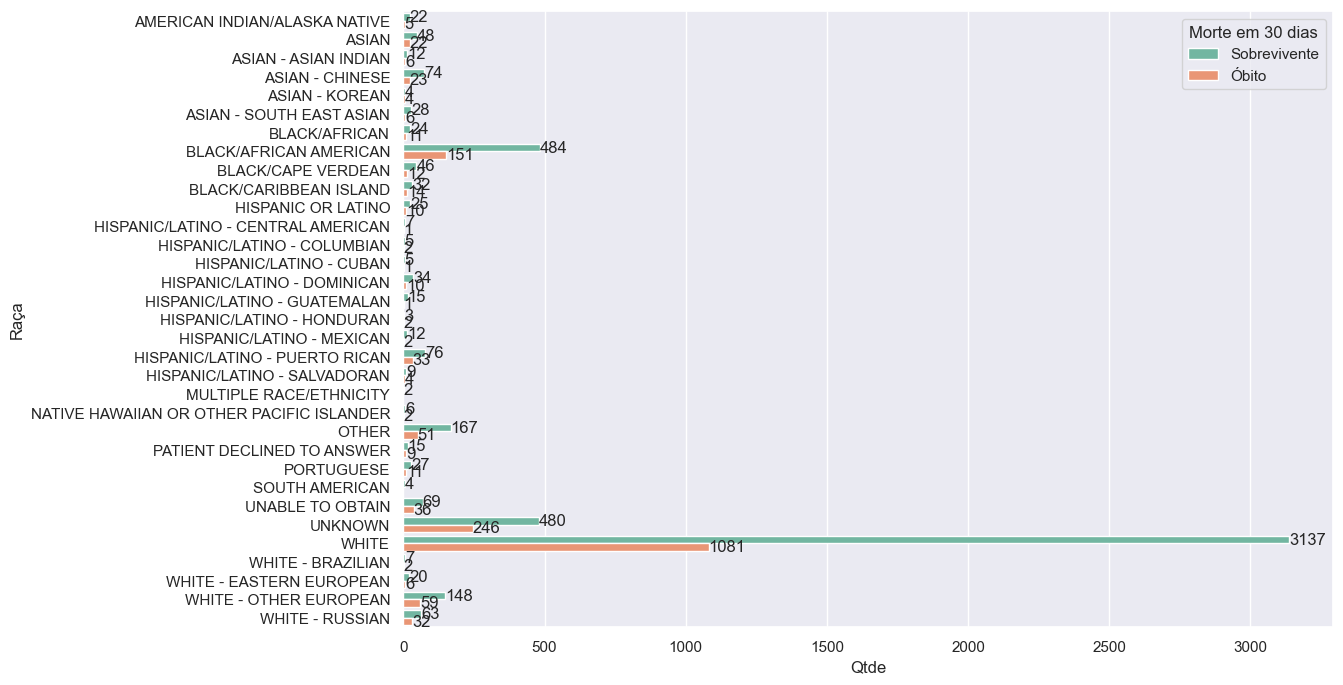

In [159]:
df_plot = patients_geral_chart.groupby(['race', 'Morte_em_30_dias']).size().reset_index(name='count')

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=df_plot,
    y='race',
    x='count',
    hue='Morte_em_30_dias',
    palette='Set2',
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=12)

plt.xlabel('Qtde')
plt.ylabel('Raça')

plt.legend(title="Morte em 30 dias")

plt.show()

In [64]:
def agrupar_raca(raca):
    if raca.startswith("ASIAN"):
        return "ASIAN"
    elif raca.startswith("BLACK"):
        return "BLACK"
    elif raca.startswith("WHITE"):
        return "WHITE"
    elif raca.startswith("HISPANIC"):
        return "HISPANIC"
    else:
        return "OUTROS"
    
patients_geral_chart['race'] = patients_geral_chart['race'].apply(agrupar_raca)

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\1041947390.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients_geral_chart['race'] = patients_geral_chart['race'].apply(agrupar_raca)


Fazendo o mesmo procedimento para Tipo de Admissão(com uma análise prévia):

In [65]:
# fazemos o mesmo processo de agrupamento:

def agrupar_tipo(tipo):
    if "EMER" in tipo or "URGENT" in tipo or "SURGICAL" in tipo :
        return "EMERGENCY"
    elif "OBSERVATION" in tipo:
        return "OBSERVATION"
    else:
        return "OUTROS"
    
patients_geral_chart['admission_type'] = patients_geral_chart['admission_type'].apply(agrupar_tipo)

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\3040630234.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients_geral_chart['admission_type'] = patients_geral_chart['admission_type'].apply(agrupar_tipo)


Agora sim, depois do ajuste, plotando as categóricas:

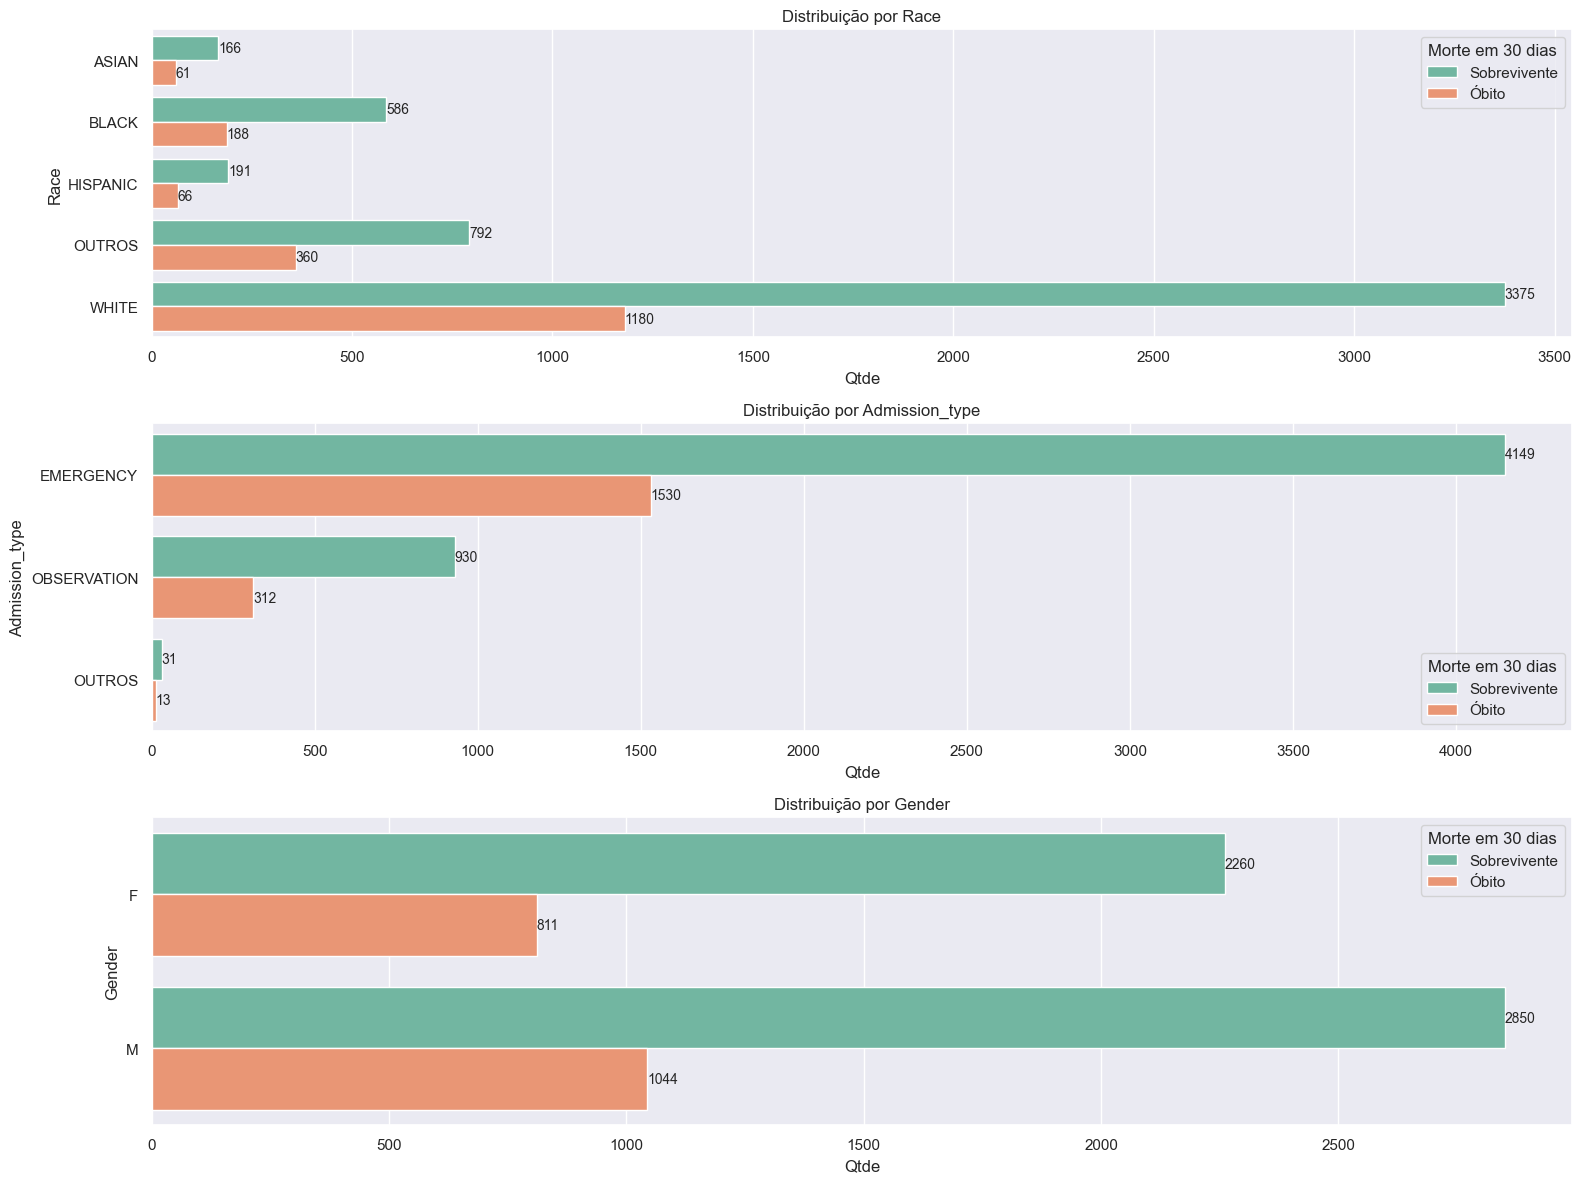

In [66]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

categ = ['race', 'admission_type', 'gender']

for i, col in enumerate(categ):

    df_plot = patients_geral_chart.groupby([col, 'Morte_em_30_dias']).size().reset_index(name='count')
    ax = sns.barplot(data=df_plot, y=col, x='count', hue='Morte_em_30_dias', palette='Set2', ax=axes[i])
    axes[i].set_xlabel('Qtde')
    axes[i].set_ylabel(col.capitalize())
    axes[i].set_title(f'Distribuição por {col.capitalize()}')
    axes[i].legend(title="Morte em 30 dias")

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=10)

plt.tight_layout()
plt.show()

Verificando as taxas de mortalidade por variável e por subcategoria

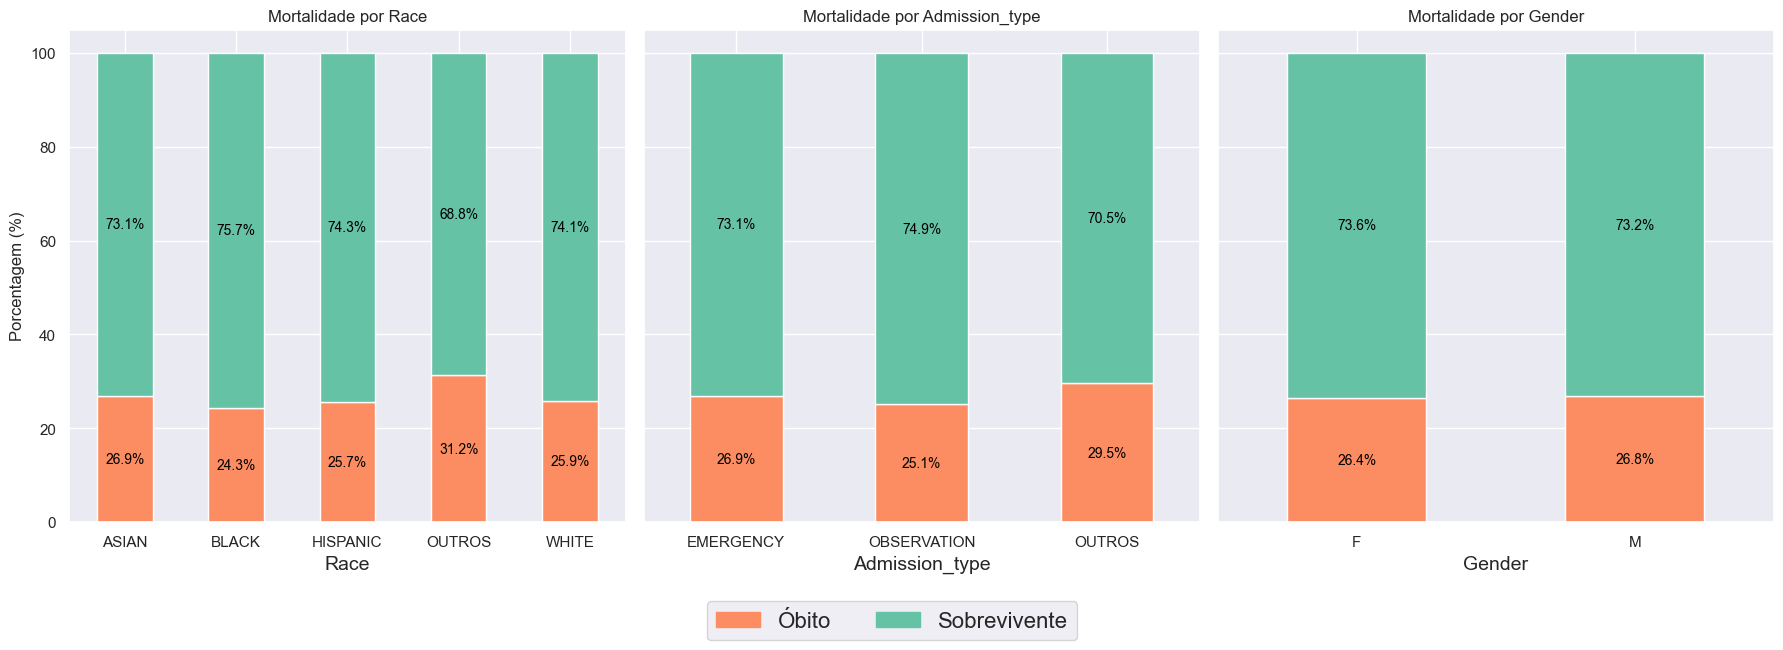

In [67]:
fig, axes = plt.subplots(1, len(categ), figsize=(18, 6), sharey=True)  # 1 linha, N colunas

for i, col in enumerate(categ):

    df_plot = patients_geral_chart.groupby([col, 'Morte_em_30_dias']).size().unstack(fill_value=0)

    df_plot = df_plot.reindex(columns=['Óbito', 'Sobrevivente'])  
    df_plot_percent = df_plot.div(df_plot.sum(axis=1), axis=0) * 100
    colors = ['#fc8d62', '#66c2a5']  
    df_plot_percent.plot(kind='bar', stacked=True, ax=axes[i], legend=False, color=colors)

    axes[i].set_xlabel(col.capitalize(), fontsize = 14)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].set_ylabel('Porcentagem (%)' if i == 0 else "") 
    axes[i].set_title(f'Mortalidade por {col.capitalize()}')

    for container in axes[i].containers:
        labels = [f"{w:.1f}%" if w > 0 else "" for w in container.datavalues]
        axes[i].bar_label(container, labels=labels, label_type='center', fontsize=10, color='black')

handles = [plt.Rectangle((0,0),1,1, color=color) for color in colors]  # Criar os handles manualmente
fig.legend(handles, ['Óbito', 'Sobrevivente'], loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize = 16)

plt.tight_layout()
plt.show()


Insights

- Raça
    - A maioria das raças tem taxas de mortalidade próximas, entretanto, Outras raças apresentam uma taxa de mortalidade em geral maior(o que pode ter uma influência genética, por exemplo, já que temos um número de amostras razoáveis de "Outros")

- Tipo de Admissão:
    - Apesar de acreditássemos ser um indicador de gravidade, o Tipo de Admissão em casos de Emergência mostrou taxas de mortalidade similares aos restantes.
    - Observe que "Outros" tem uma taxa de mortalidade maior, mas isso é devido ao pouco número de amostras. Logo, não podemos concluir muito sobre.

- Gênero:
    - Com taxas de mortalidade muito próximas, o gênero parece não influir muito na mortalidade

Talvez valesse a pena remover essas variáveis do modelo, já que não parecem influenciar significativamente.

### Analisando a correlação entre as variáveis representativas

C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\4176773574.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr['Morte_em_30_dias'] = df_corr['Morte_em_30_dias'].replace({'Sobrevivente': 0, 'Óbito': 1})
C:\Users\Felipe 1\AppData\Local\Temp\ipykernel_13288\4176773574.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr['Morte_em_30_dias'] = df_corr['Morte_em_30_dias'].replace({'Sobrevivente': 0, 'Óbito': 1})


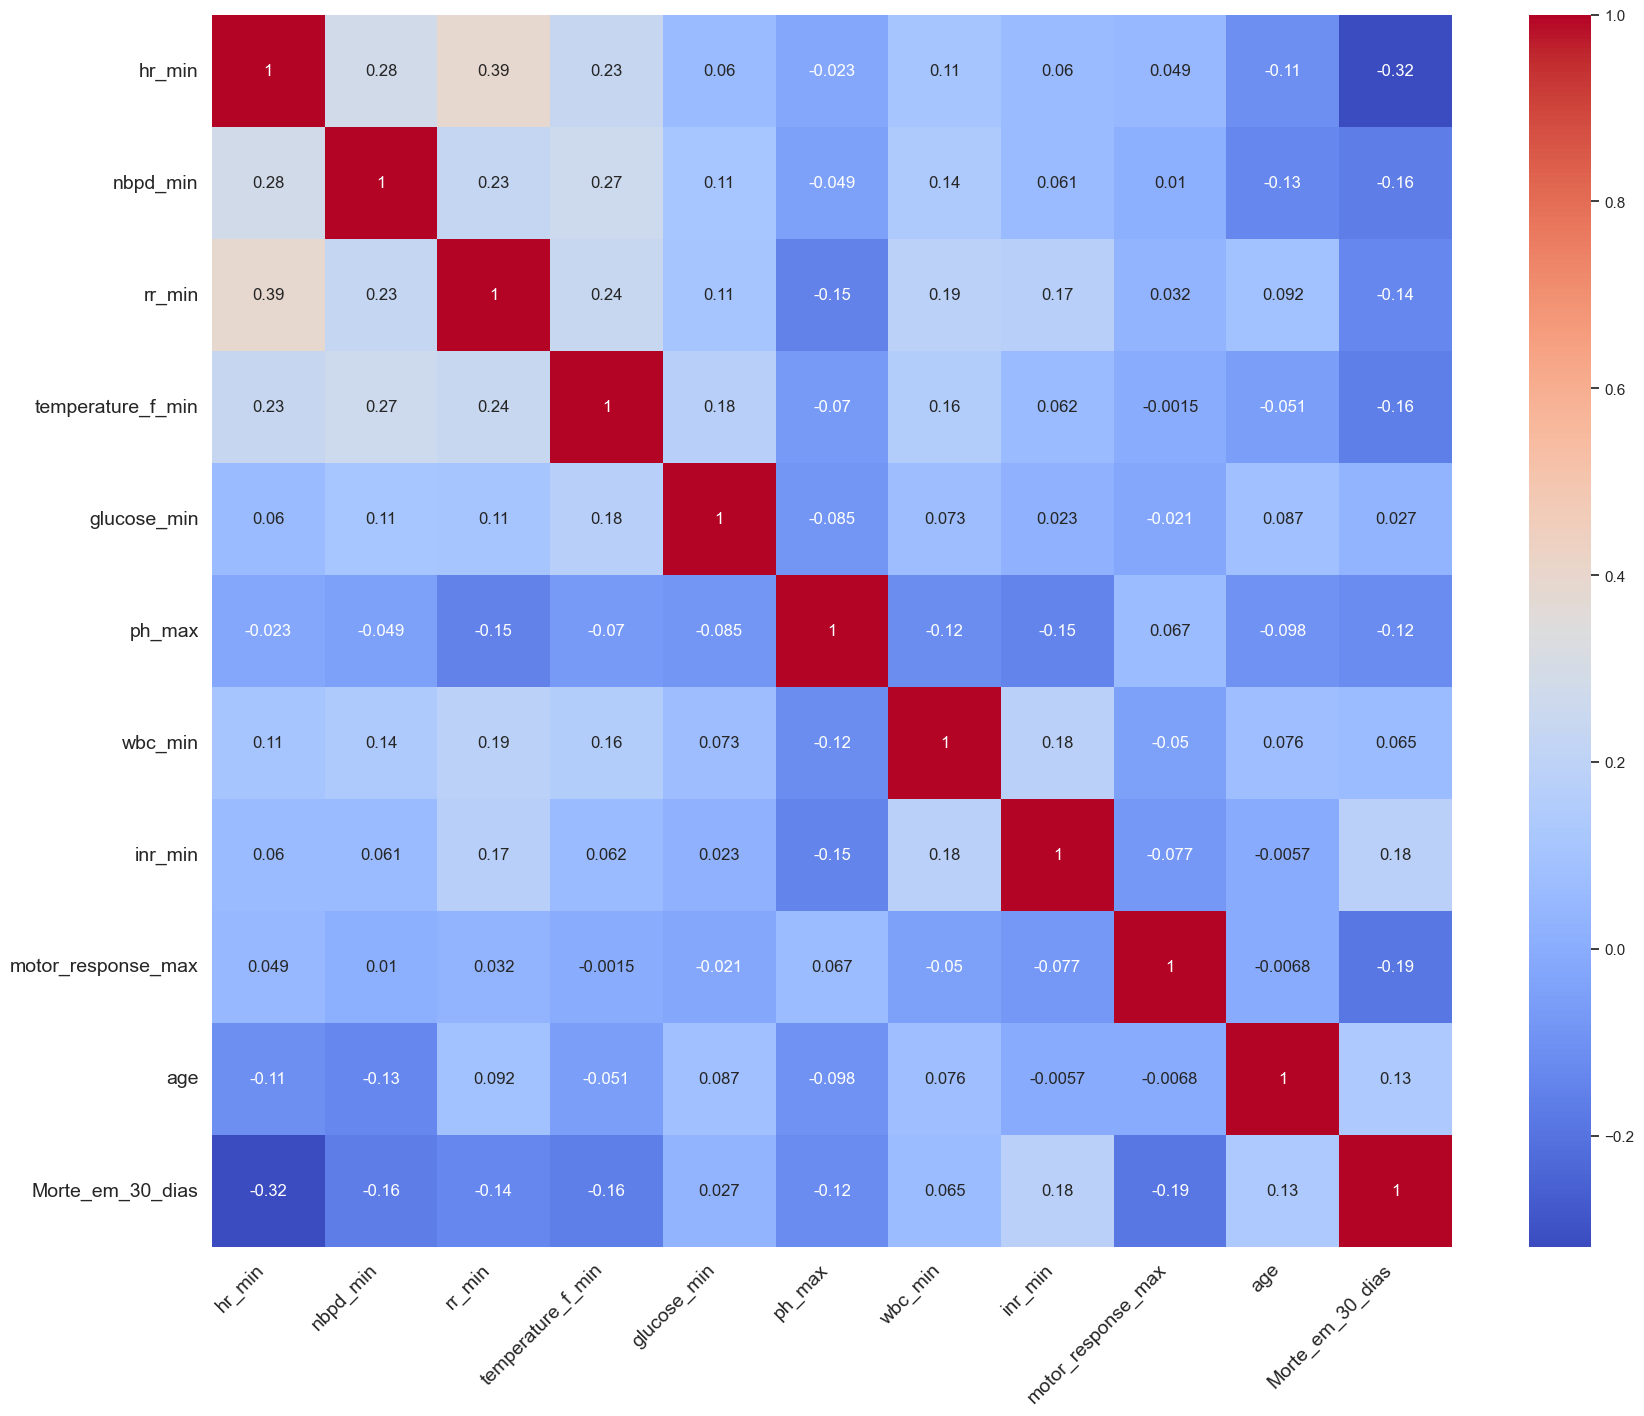

In [76]:
df_corr = patients_geral_chart[variaveis_represent + ['age', 'Morte_em_30_dias']]

df_corr['Morte_em_30_dias'] = df_corr['Morte_em_30_dias'].replace({'Sobrevivente': 0, 'Óbito': 1})
matriz_corr = df_corr.corr()

plt.figure(figsize=(20, 16))
ax = sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')

# Ajustar tamanho das fontes dos eixos
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14, rotation=45, ha='right')  # Ajusta a fonte do eixo X
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, rotation=0)  # Ajusta a fonte do eixo Y

plt.show()



Comentários da Correlação:


Se algumas variáveis estão boas, vamos olhar alguns scatter plot

- Correlações com `Morte_em_30_dias`:
    - `hr_min (-0.32)`: Frequência cardíaca mínima tem a maior correlação com mortalidade, sugerindo que frequências muito baixas aumentam o risco de óbito.  
    - `age (+0.13)`: Idade tem uma correlação positiva, indicando que pacientes mais velhos têm maior risco de mortalidade.  
    - `inr_min (+0.18)`: Tempo de coagulação (INR) mais alto pode estar associado a maior mortalidade.  
    - `wbc_min (+0.065)`: Contagem mínima de leucócitos tem correlação fraca, mas pode indicar impacto na resposta imune.  
    - Variáveis como `glucose_min`, `ph_max`, `motor_response_max`, `nbpd_min` e `temperature_f_min` têm correlação muito fraca com mortalidade, indicando que isoladamente não são bons preditores.  
    - `motor_response_max (-0.19)` tem uma leve correlação negativa, sugerindo que menor resposta motora pode estar associada a maior risco de óbito.  

- Correlações Entre Variáveis:
    - `hr_min` e `rr_min` (+0.39): Relação entre frequência cardíaca e respiratória.  
    - `ph_max` e `rr_min` (-0.15): Possível impacto de distúrbios ácido-base(associados a respiração).
    - `age` não tem forte correlação com variáveis clínicas, mas tem leve impacto na mortalidade.

Dessas variáveis que tem certa correlação entre si, avaliei alguns Scatter Plots, mas não pareciam ter um padrão de relação, então não coloquei aqui

Salvando para usarmos nos modelos

In [80]:
patients_geral_chart.reset_index(drop= True, inplace= True)
patients_geral_chart

,subject_id,admission_type,race,gender,verbal_response_max,urea_nitrogen_min,anion_gap_min,anion_gap_max,braden_sensory_perception_max,lactate_min,...,secondary_diagnosis_max,mchc_min,resp_alarm_-_high_min,temperature_f_min,hemoglobin_min,sodium_(serum)_min,hematocrit_max,hematocrit_(serum)_min,admission_weight_(kg)_max,Morte_em_30_dias
0,10002428,EMERGENCY,WHITE,F,5.0,13.0,6.0,21.0,4.0,1.2,...,15.0,30.7,30.0,97.000000,7.4,128.0,36.9,23.100000,55.000000,Sobrevivente
1,10003400,EMERGENCY,BLACK,F,5.0,27.0,8.0,23.0,4.0,0.8,...,15.0,31.7,30.0,95.199997,5.2,128.0,27.2,19.900000,99.599998,Óbito
2,10003637,EMERGENCY,OUTROS,M,5.0,42.0,15.0,22.0,4.0,0.8,...,15.0,30.7,35.0,94.900002,10.1,132.0,42.8,31.799999,88.000000,Óbito
3,10004235,EMERGENCY,BLACK,M,5.0,32.0,13.0,28.0,4.0,1.4,...,15.0,31.9,35.0,98.000000,8.5,129.0,38.7,29.400000,127.000000,Sobrevivente
4,10004401,EMERGENCY,WHITE,M,5.0,48.0,11.0,30.0,4.0,1.0,...,15.0,30.5,20.0,97.500000,6.2,125.0,32.8,19.799999,90.699997,Óbito
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6960,19985545,OBSERVATION,WHITE,M,5.0,8.0,5.0,13.0,4.0,1.0,...,15.0,30.7,30.0,97.199997,6.0,126.0,26.2,20.000000,75.000000,Sobrevivente
6961,19986880,EMERGENCY,OUTROS,F,5.0,20.0,14.0,32.0,4.0,1.7,...,15.0,33.5,30.0,97.500000,7.9,126.0,38.0,24.799999,58.799999,Óbito
6962,19988077,EMERGENCY,WHITE,M,5.0,11.0,9.0,18.0,4.0,1.4,...,15.0,32.0,30.0,97.199997,7.7,131.0,33.1,22.500000,71.000000,Sobrevivente
6963,19991446,EMERGENCY,WHITE,F,5.0,15.0,6.0,18.0,4.0,0.6,...,15.0,31.4,35.0,97.000000,6.4,139.0,30.5,19.100000,58.000000,Sobrevivente


In [81]:
patients_geral_chart.to_excel('patients_tratado.xlsx', index = False)